[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/information_theory/03_cross_entropy_and_loss_functions/first_principles.ipynb)

# Module 03 — Cross-Entropy and Loss Functions

## 1. Why This Module Exists

Entropy measures what it costs to describe a source whose distribution you know. No model
knows it. A model carries an approximation $q$ of an unknown truth $p$.

This module answers the operational question that replaces it: **what do you pay for acting
on $q$ when reality follows $p$?**

The answer is a single identity. The bill splits into a part nobody can avoid and a part that
is entirely the modeller's fault, and the second part is never negative.

That identity is why one function — cross-entropy — is simultaneously the length of a
mis-designed code, the negative log-likelihood of a statistical model, the loss minimized by
every classifier and language model, and the growth rate lost by a gambler with wrong beliefs.

## 2. Intuition

Imagine you must design a codebook before seeing any data. You believe symbol $x$ arrives with
probability $q(x)$, so you give it a codeword of about $-\log_2 q(x)$ bits: likely symbols get
short words, unlikely ones long words.

Then reality starts sending symbols at frequencies $p(x)$. Your average bill per symbol is not
$H(q)$ and not $H(p)$; it is the expectation **under $p$** of the cost schedule designed for
$q$.

Two things can make that bill large. The source may be genuinely unpredictable, which costs
$H(p)$ and cannot be helped. Or your beliefs may be wrong, which costs extra.

Picture the bill as a function of the single number $q$ in a two-outcome world. It is a convex
curve, it has one minimum, and the minimum sits at $q = p$ at height $H(p)$ — never at zero.
The vertical distance from that floor up to the curve is the whole penalty for being wrong.

Everything below is that picture made exact, then applied to the loss functions actually
descended by stochastic gradient descent.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single
random generator used everywhere below, prints the machine epsilon that later residual claims
are measured against, and defines the four information-theoretic quantities used throughout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")


def entropy(p, base=2.0):
    """H(p) with the convention 0 log 0 = 0."""
    p = np.asarray(p, dtype=float)
    m = p > 0
    return float(-(p[m] * np.log(p[m])).sum() / np.log(base))


def cross_entropy(p, q, base=2.0):
    """H_x(p, q) = -sum p log q, summed over the support of p only."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    m = p > 0
    with np.errstate(divide="ignore"):
        return float(-(p[m] * np.log(q[m])).sum() / np.log(base))


def kl(p, q, base=2.0):
    """D_KL(p || q), summed over the support of p only."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    m = p > 0
    with np.errstate(divide="ignore"):
        return float((p[m] * np.log(p[m] / q[m])).sum() / np.log(base))


def binary_entropy(t, base=2.0):
    """H_b(t) for a scalar or array argument."""
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    m = (t > 0) & (t < 1)
    out[m] = -(t[m] * np.log(t[m]) + (1 - t[m]) * np.log(1 - t[m])) / np.log(base)
    return out


print("H(1/2, 1/4, 1/8, 1/8) =", entropy([0.5, 0.25, 0.125, 0.125]), "bits")

machine epsilon = 2.2204e-16
H(1/2, 1/4, 1/8, 1/8) = 1.75 bits


Every residual reported later is quoted as a multiple of that machine epsilon. The printed
$1.75$ bits is the entropy of the running four-symbol example of Section 6.

The next cell draws the picture described above. The left panel fixes $p = (0.8, 0.2)$ and
sweeps the reported probability $q_1$ across $(0,1)$, plotting

$$
H_{\times}(p, q) = -0.8 \log_2 q_1 - 0.2 \log_2 (1 - q_1),
$$

with the floor $H(p)$ and the gap $D_{\mathrm{KL}}(p \parallel q)$ marked at one wrong report.
The right panel plots the binary entropy $H_b$, which is the value of that floor as $p_1$
varies.

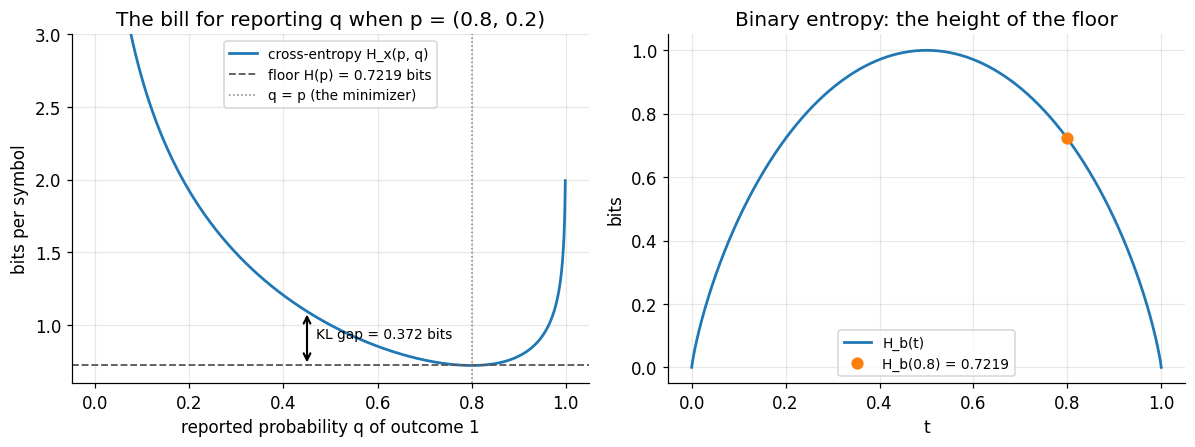

minimum of the swept curve : 0.721928 bits at q = 0.800
H(p)                       : 0.721928 bits
cost at the wrong report q = 0.45: 1.094102 bits, excess 0.372174


In [2]:
p_bin = np.array([0.8, 0.2])
grid = np.linspace(0.001, 0.999, 999)
ce_curve = -(p_bin[0] * np.log2(grid) + p_bin[1] * np.log2(1 - grid))
floor = entropy(p_bin)
q_bad = 0.45
ce_bad = -(p_bin[0] * np.log2(q_bad) + p_bin[1] * np.log2(1 - q_bad))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.0, 4.2))

axL.plot(grid, ce_curve, lw=1.8, label="cross-entropy H_x(p, q)")
axL.axhline(floor, lw=1.2, ls="--", color="0.35", label=f"floor H(p) = {floor:.4f} bits")
axL.axvline(p_bin[0], lw=1.0, ls=":", color="0.5", label="q = p (the minimizer)")
axL.annotate("", xy=(q_bad, ce_bad), xytext=(q_bad, floor),
             arrowprops=dict(arrowstyle="<->", lw=1.4))
axL.text(q_bad + 0.02, (ce_bad + floor) / 2,
         f"KL gap = {ce_bad - floor:.3f} bits", fontsize=9)
axL.set_ylim(0.6, 3.0)
axL.set_xlabel("reported probability q of outcome 1")
axL.set_ylabel("bits per symbol")
axL.set_title("The bill for reporting q when p = (0.8, 0.2)")
axL.legend(fontsize=9)

t = np.linspace(0.0, 1.0, 501)
axR.plot(t, binary_entropy(t), lw=1.8, label="H_b(t)")
axR.plot([p_bin[0]], [floor], "o", ms=7, label=f"H_b(0.8) = {floor:.4f}")
axR.set_xlabel("t")
axR.set_ylabel("bits")
axR.set_title("Binary entropy: the height of the floor")
axR.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"minimum of the swept curve : {ce_curve.min():.6f} bits at q = {grid[ce_curve.argmin()]:.3f}")
print(f"H(p)                       : {floor:.6f} bits")
print(f"cost at the wrong report q = {q_bad}: {ce_bad:.6f} bits, excess {ce_bad - floor:.6f}")

The swept minimum lands at $q = 0.8$ with height $0.7219$ bits, which is exactly $H(p)$: the
curve touches its floor only at the truth.

Reporting $q_1 = 0.45$ instead costs $1.09410$ bits, an excess of $0.37217$ bits per symbol.
That excess is the KL divergence, and Theorem 4.1 says it can never be negative.

The right panel says what the floor itself depends on: only the source. A deterministic source
has floor zero, a fair coin has floor one bit, and no model of any quality moves that number.

## 3. Definitions

Throughout, $\mathcal{X}$ is a finite alphabet of size $K$, and $p, q$ are probability mass
functions on $\mathcal{X}$. The conventions are fixed in
[the notation register](../../docs/notation.md); three of them matter here.

Logarithms are base $2$ (units: **bits**) unless a formula is explicitly in nats, and every
numerical answer carries its unit.

The two-argument $H$ is already taken: $H(X, Y)$ is the **joint entropy** of a pair of random
variables, as in
[Module 02](../02_joint_and_conditional_entropy/first_principles.ipynb). Cross-entropy is a
function of two *distributions* and is written $H_{\times}(p, q)$ throughout this repository.
The machine-learning literature calls the same quantity $\mathrm{CE}$.

### Definition 3.1 — Cross-entropy

Let $p$ and $q$ be pmfs on $\mathcal{X}$. The **cross-entropy** of $q$ relative to $p$ is

$$
H_{\times}(p, q) = -\sum_{x \,:\, p(x) \gt 0} p(x) \log q(x)
= \mathbb{E}_{X \sim p}\left[-\log q(X)\right].
$$

The sum runs over $\operatorname{supp}(p) = \{x : p(x) \gt 0\}$, so the convention
$0 \log 0 = 0$ is built in rather than assumed.

If $q(x) = 0$ for some $x$ with $p(x) \gt 0$ — that is, if $p$ is not absolutely continuous
with respect to $q$ — then $H_{\times}(p, q) = +\infty$.

### Definition 3.2 — Kullback-Leibler divergence

For pmfs $p, q$ on $\mathcal{X}$,

$$
D_{\mathrm{KL}}(p \parallel q) = \sum_{x \,:\, p(x) \gt 0} p(x) \log \frac{p(x)}{q(x)} .
$$

It is defined here rather than imported, because everything this module proves about it is
proved here. [Module 04](../04_kl_divergence_and_f_divergences/) later embeds it in the family
of $f$-divergences.

### Definition 3.3 — Binary cross-entropy, softmax, and the classification loss

For a label $y \in \{0, 1\}$ and a predicted probability $\hat{p} \in (0, 1)$, the **binary
cross-entropy** (log loss) is

$$
\mathrm{BCE}(y, \hat{p}) = -y \log \hat{p} - (1-y) \log (1 - \hat{p}) .
$$

For logits $z \in \mathbb{R}^K$ the **softmax** distribution and the **softmax cross-entropy
loss** against a target vector $y$ on the simplex are

$$
q_k = \operatorname{softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}},
\qquad
\mathcal{L}(z) = -\sum_{k=1}^{K} y_k \log q_k = H_{\times}(y, q) .
$$

A one-hot $y$ makes $\mathcal{L}(z) = -\log q_{\text{true}}$; a soft $y$ is the label-smoothing
or distillation case.

### Definition 3.4 — Scoring rule: proper, strictly proper, local

A **scoring rule** $S(q, x)$ is the loss charged when the forecaster reports the distribution
$q$ and the outcome $x$ occurs. Write

$$
\bar{S}(p, q) = \mathbb{E}_{X \sim p}\left[S(q, X)\right] = \sum_x p(x) S(q, x) .
$$

The rule is **proper** when $\bar{S}(p, p) \le \bar{S}(p, q)$ for all $p, q$, and **strictly
proper** when equality forces $q = p$.

It is **local** when $S(q, x)$ depends on $q$ only through the single number $q(x)$, that is
$S(q, x) = s(q(x))$ for some function $s$.

### Definition 3.5 — Prefix code, Kraft sum, expected length

A **binary prefix code** on $\mathcal{X}$ assigns to each $x$ a finite binary string $c(x)$ such
that no codeword is a prefix of another. Write $\ell(x) = \lvert c(x) \rvert$ for its length in
bits.

The **Kraft sum** of a length assignment $\ell : \mathcal{X} \to \mathbb{N}$ is

$$
\mathcal{K}(\ell) = \sum_{x \in \mathcal{X}} 2^{-\ell(x)} ,
$$

and the **expected length** under a source $p$ is
$\mathbb{E}_p[\ell] = \sum_x p(x) \ell(x)$ bits per symbol.

## 4. Main Results

Theorem 4.1 is the identity the module is named after; everything else either explains what it
means operationally or turns it into a training objective.

Theorems 4.2 and 4.3 supply the coding interpretation, so that "cross-entropy is the length of
the wrong code" becomes a theorem with a $+1$ instead of a slogan. Theorems 4.4 and 4.5 are the
statistical and computational faces, Theorems 4.6 and 4.7 explain why the logarithm and not
some other loss, and Theorems 4.8 to 4.9 cover the two modifications used in practice.
Proposition 4.10 measures how far a fitted model's training loss sits below its true loss.

### Theorem 4.1 — Cross-entropy decomposition and Gibbs' inequality

Let $p, q$ be pmfs on a finite alphabet $\mathcal{X}$ with $q(x) \gt 0$ for every
$x \in \operatorname{supp}(p)$. Then

$$
H_{\times}(p, q) = H(p) + D_{\mathrm{KL}}(p \parallel q),
$$

and

$$
D_{\mathrm{KL}}(p \parallel q) \ge 0, \qquad
D_{\mathrm{KL}}(p \parallel q) = 0 \iff p = q .
$$

Consequently $H_{\times}(p, q) \ge H(p)$ with equality exactly at $q = p$.

**Hypotheses.** Finiteness of $\mathcal{X}$ lets every sum be rearranged without a convergence
argument. Absolute continuity — $q \gt 0$ on $\operatorname{supp}(p)$ — is what keeps both
sides finite; drop it and the left side is $+\infty$ while the right side is still a sum of
finite terms plus $+\infty$, so the identity survives only in the trivial sense that both sides
are infinite. Section 7.3 runs that case.

Proved as Proof 5.1.

### Theorem 4.2 — Kraft's inequality and its converse

Let $\mathcal{X}$ be finite.

**(a)** Every binary prefix code on $\mathcal{X}$ has $\mathcal{K}(\ell) \le 1$.

**(b)** Conversely, for every length assignment $\ell : \mathcal{X} \to \mathbb{N}$ with
$\mathcal{K}(\ell) \le 1$ there exists a binary prefix code with exactly those lengths.

**Hypotheses.** The prefix property is doing the work in (a). The three-symbol code
$\{0, 01, 1\}$ assigns distinct strings and is therefore a code, yet its Kraft sum is
$\tfrac12 + \tfrac14 + \tfrac12 = \tfrac54 \gt 1$; it is not uniquely decodable either, since
the string $01$ parses two ways. Uniquely decodable codes do satisfy Kraft, but that requires the
separate McMillan argument (Cover and Thomas, *Elements of Information Theory*, 2nd ed.,
Theorem 5.5.1). Integrality of the lengths is what makes (b) a statement about codes, which have
whole-number lengths. Section 7.3 runs the counterexample.

Proved as Proof 5.2.

### Theorem 4.3 — The wrong-code theorem

Let $p, q$ be pmfs on a finite $\mathcal{X}$ with $q \gt 0$ everywhere, and let $\ell_q$ be the
**Shannon code for $q$**, $\ell_q(x) = \lceil -\log_2 q(x) \rceil$. Then $\ell_q$ satisfies
Kraft, so by Theorem 4.2(b) it is realizable by a prefix code, and

$$
H(p) + D_{\mathrm{KL}}(p \parallel q) \;\le\; \mathbb{E}_p[\ell_q] \;\lt\; H(p) + D_{\mathrm{KL}}(p \parallel q) + 1
$$

bits per symbol. Both bounds are attained in the limit: the left one with equality whenever
$q$ is dyadic, the right one approached as $q$ concentrates.

**Hypotheses.** $q \gt 0$ everywhere is needed for $\ell_q$ to be finite. $p$ enters only
through the expectation, so no relation between $p$ and $q$ is required beyond both being pmfs
on the same alphabet.

**Interpretation.** Cross-entropy is not *like* a code length; it is a code length to within
one bit, and the excess over the best possible code is exactly the KL divergence. This is
Cover and Thomas, *Elements of Information Theory*, 2nd ed., Theorem 5.4.3.

Proved as Proof 5.3.

### Theorem 4.4 — Maximum likelihood is empirical cross-entropy minimization

Let $y_1, \dots, y_N \in \mathcal{X}$ be observations, let $\hat{p}_N$ be their empirical
distribution, and let $\{q_\theta\}$ be a family of pmfs with $q_\theta \gt 0$ on
$\operatorname{supp}(\hat{p}_N)$. Then the log-likelihood is

$$
\ell(\theta) = \sum_{i=1}^{N} \log q_\theta(y_i) = -N \, H_{\times}(\hat{p}_N, q_\theta),
$$

so that

$$
\operatorname*{arg\,max}_{\theta} \ell(\theta)
= \operatorname*{arg\,min}_{\theta} H_{\times}(\hat{p}_N, q_\theta)
= \operatorname*{arg\,min}_{\theta} D_{\mathrm{KL}}(\hat{p}_N \parallel q_\theta) .
$$

If the family is the whole simplex, the unique maximizer is $q = \hat{p}_N$.

**Hypotheses.** The observations must be scored by the same $q_\theta$ that the empirical
distribution counts, which is what makes the sum collapse; positivity on the observed support
keeps $\ell(\theta)$ finite. Independence is *not* needed for the identity — only for
interpreting $\hat p_N$ as an estimate of $p$.

Proved as Proof 5.4.

### Theorem 4.5 — Softmax cross-entropy: gradient and convexity

Let $\mathcal{L}(z) = -\sum_k y_k \log q_k$ with $q = \operatorname{softmax}(z)$ and
$\sum_k y_k = 1$, $y_k \ge 0$. Then, in nats,

$$
\frac{\partial \mathcal{L}}{\partial z_m} = q_m - y_m,
\qquad
\nabla^2 \mathcal{L}(z) = \operatorname{diag}(q) - q q^{\top} \succeq 0 .
$$

In particular $\mathcal{L}$ is convex in $z$, its gradient has entries in $[-1, 1]$, and the
gradient sums to zero.

**Hypotheses.** $\sum_k y_k = 1$ is what lets the normalizer be pulled out of the sum; without
it the gradient is $\left(\sum_k y_k\right) q - y$, which Section 7.3 exhibits numerically.
Non-negativity of $y$ is not needed for the gradient formula, only for reading $y$ as a
distribution.

Proved as Proof 5.5.

### Theorem 4.6 — The logarithmic score is strictly proper

The rule $S(q, x) = -\log q(x)$ satisfies

$$
\bar{S}(p, q) = H_{\times}(p, q) \;\ge\; H(p) = \bar{S}(p, p),
$$

with equality if and only if $q = p$. Hence it is strictly proper: a forecaster judged by log
loss minimizes expected loss by reporting exactly its beliefs.

**Hypotheses.** Only those of Theorem 4.1, from which this is immediate. Strictness is
inherited from the strictness of Gibbs' inequality.

Proved as Proof 5.6.

### Theorem 4.7 — Locality forces the logarithm

Let $K = \lvert \mathcal{X} \rvert \ge 3$ and let $S(q, x) = s(q(x))$ be a local scoring rule
with $s$ differentiable on $(0,1)$. If $S$ is proper — so that for every $p$ in the interior of
the simplex the map $q \mapsto \bar{S}(p, q)$ is stationary at $q = p$ — then there are
constants $a$ and $b \gt 0$ with

$$
s(t) = a - b \log t .
$$

**Hypotheses.** $K \ge 3$ is not cosmetic: for $K = 2$ the constraint $q_2 = 1 - q_1$ makes
every rule local, and the binary Brier score $s(t) = 2(1-t)^2$ is then local, strictly proper
and *not* of the logarithmic form. Section 7.3 runs that counterexample. Differentiability
replaces the weaker regularity used in the literature.

**Attribution.** The general smooth version is Bernardo, J. M., "Expected information as
expected utility", *Annals of Statistics* **7**(3) (1979), 686-690, Theorem 1; the proof below
is the differentiable case, which is all this module uses.

Proved as Proof 5.7.

### Theorem 4.8 — Label smoothing has an interior optimum

Fix a one-hot target $y$ on $K$ classes, a smoothing level $\epsilon \in (0,1)$, and the
uniform $u_k = 1/K$. Put $\tilde{y} = (1-\epsilon) y + \epsilon u$. Then

$$
H_{\times}(\tilde{y}, q) = (1-\epsilon) H_{\times}(y, q) + \epsilon H_{\times}(u, q),
$$

the minimizer over the simplex is $q^{\star} = \tilde{y}$, the optimal confidence in the true
class is

$$
q^{\star}_{\text{true}} = 1 - \epsilon + \frac{\epsilon}{K},
$$

and the optimal logit gap between the true class and any other is the finite number

$$
z_{\text{true}} - z_{\text{other}} = \log \frac{(1-\epsilon)K + \epsilon}{\epsilon} .
$$

**Hypotheses.** $\epsilon \gt 0$ is what makes every target coordinate positive and hence the
optimal logit gap finite; at $\epsilon = 0$ the optimum is a vertex of the simplex and the gap
diverges, which Section 7.3 exhibits numerically. $\epsilon \lt 1$ keeps the true class
distinguished.

Proved as Proof 5.8.

### Theorem 4.9 — Matching loss: sigmoid with BCE against sigmoid with squared error

Let $\hat{p} = \sigma(z) = (1 + e^{-z})^{-1}$ and $y \in \{0,1\}$. Then

$$
\frac{\partial}{\partial z}\,\mathrm{BCE}(y, \sigma(z)) = \sigma(z) - y,
\qquad
\frac{\partial^2}{\partial z^2}\,\mathrm{BCE}(y, \sigma(z)) = \sigma(z)\bigl(1 - \sigma(z)\bigr) \gt 0,
$$

so BCE is strictly convex in the logit, whereas for
$\mathcal{L}_{\mathrm{MSE}} = \tfrac12 (\sigma(z) - y)^2$,

$$
\frac{\partial \mathcal{L}_{\mathrm{MSE}}}{\partial z} = \bigl(\sigma(z) - y\bigr)\, \sigma(z)\bigl(1 - \sigma(z)\bigr),
$$

which tends to $0$ as $z \to -\infty$ with $y = 1$, and $\mathcal{L}_{\mathrm{MSE}}$ is
non-convex in $z$.

**Hypotheses.** The link must be the logistic sigmoid: the cancellation is between $\sigma'$
and the derivative of the log, and it is exactly the statement that the sigmoid is the
canonical link of the Bernoulli family. For a different link the two derivatives no longer
cancel.

Proved as Proof 5.9.

### Proposition 4.10 — The optimism of the plug-in model

Let $\hat{p}_N$ be the empirical distribution of $N$ i.i.d. draws from a pmf $p$ with
$p(x) \gt 0$ for all $K$ symbols. Then, in nats,

$$
\mathbb{E}\left[H_{\times}(\hat{p}_N, p) - H(\hat{p}_N)\right]
= \mathbb{E}\left[D_{\mathrm{KL}}(\hat{p}_N \parallel p)\right]
= \frac{K-1}{2N} + O\!\left(N^{-2}\right).
$$

**Hypotheses.** Strict positivity of $p$ keeps the Taylor expansion valid on a set of
probability tending to $1$ fast enough; i.i.d. sampling gives the multinomial variance
$p_x(1-p_x)/N$ used in the proof.

**Interpretation.** Fitting the empirical distribution buys $(K-1)/(2N)$ nats of training loss
that do not exist in the truth. It is the information-theoretic form of the AIC penalty, and
Section 7.2 measures it.

Proved as Proof 5.10.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, decomposition and Gibbs' inequality)

**Step 1 — the decomposition is algebra.** For every $x \in \operatorname{supp}(p)$,

$$
-p(x) \log q(x) = -p(x) \log p(x) + p(x) \log \frac{p(x)}{q(x)} .
$$

Summing over $\operatorname{supp}(p)$ gives
$H_{\times}(p, q) = H(p) + D_{\mathrm{KL}}(p \parallel q)$. No inequality has been used yet.

**Step 2 — the tangent-line bound.** For $t \gt 0$,

$$
\ln t \le t - 1,
$$

with equality if and only if $t = 1$. Proof: $g(t) = t - 1 - \ln t$ has $g(1) = 0$,
$g'(t) = 1 - 1/t$ and $g''(t) = 1/t^2 \gt 0$, so $g$ is strictly convex with its only
stationary point a minimum at $t = 1$.

This is proved here, in three lines, precisely so that nothing in this module depends on a
later one.

**Step 3 — apply it on the support of $p$.** Write $A = \operatorname{supp}(p)$ and work in
nats. For $x \in A$ put $t = q(x)/p(x) \gt 0$:

$$
-D_{\mathrm{KL}}(p \parallel q) = \sum_{x \in A} p(x) \ln \frac{q(x)}{p(x)}
\;\le\; \sum_{x \in A} p(x)\left(\frac{q(x)}{p(x)} - 1\right)
= \sum_{x \in A} q(x) \;-\; \sum_{x \in A} p(x) .
$$

The two sums are **not** over the same index set by accident: $\sum_{x \in A} p(x) = 1$ because
$A$ carries all of $p$, while $\sum_{x \in A} q(x) \le 1$ because $q$ may place mass outside
$A$. Hence

$$
-D_{\mathrm{KL}}(p \parallel q) \le 1 - 1 = 0 .
$$

**Step 4 — the equality case.** Equality in Step 3 forces two things at once. The tangent-line
bound is tight only at $t=1$, so $q(x) = p(x)$ for every $x \in A$; and the final inequality is
tight only if $\sum_{x \in A} q(x) = 1$, so $q$ places no mass outside $A$. Together these say
$q = p$. Conversely $p = q$ gives $D_{\mathrm{KL}} = 0$ term by term.

$$
\boxed{H_{\times}(p, q) = H(p) + D_{\mathrm{KL}}(p \parallel q) \ge H(p), \qquad \text{equality} \iff p = q}
$$

**Interpretation.** The expected cost of acting on $q$ splits into a term the modeller cannot
touch and a term that is zero only at the truth. The consequence is that minimizing
cross-entropy over $q$ is a well-posed way to recover $p$: the objective has one global
minimum, and it sits exactly at the right answer. $\blacksquare$

### Proof 5.2 (of Theorem 4.2, Kraft's inequality and its converse)

**(a) Prefix implies Kraft.** Let $L = \max_x \ell(x)$ and consider the complete binary tree of
depth $L$, which has $2^L$ leaves.

A codeword of length $\ell(x)$ is a node at depth $\ell(x)$; the strings of length $L$ that
extend it are exactly the $2^{L - \ell(x)}$ leaves below that node.

The prefix property says no codeword lies below another, so these leaf sets are pairwise
disjoint. Counting leaves,

$$
\sum_{x} 2^{L - \ell(x)} \le 2^{L},
$$

and dividing by $2^L$ gives $\mathcal{K}(\ell) \le 1$.

**(b) Kraft implies a prefix code exists.** Sort the alphabet so that
$\ell_1 \le \ell_2 \le \dots \le \ell_K$ and define the cumulative sums

$$
w_j = \sum_{i \lt j} 2^{-\ell_i} \in [0, 1),
$$

which are increasing and bounded by $\mathcal{K}(\ell) \le 1$. Let $c_j$ be the first $\ell_j$
bits of the binary expansion of $w_j$.

Suppose $c_i$ were a prefix of $c_j$ for some $i \lt j$. Then $w_j$ and $w_i$ agree in their
first $\ell_i$ bits, so $w_j - w_i \lt 2^{-\ell_i}$.

But by construction $w_j - w_i = \sum_{i \le m \lt j} 2^{-\ell_m} \ge 2^{-\ell_i}$, a
contradiction. Hence the $c_j$ form a prefix code with the prescribed lengths. $\blacksquare$

**Interpretation.** Kraft turns the combinatorial question "which code lengths exist?" into the
analytic question "which sub-probability vectors exist?", through $q(x) = 2^{-\ell(x)}$. That
change of variables is what makes the next theorem a statement about distributions.

### Proof 5.3 (of Theorem 4.3, the wrong-code theorem)

**Step 1 — the code exists.** With $\ell_q(x) = \lceil -\log_2 q(x) \rceil$ we have
$\ell_q(x) \ge -\log_2 q(x)$, hence $2^{-\ell_q(x)} \le q(x)$ and

$$
\mathcal{K}(\ell_q) = \sum_x 2^{-\ell_q(x)} \le \sum_x q(x) = 1 .
$$

By Theorem 4.2(b) a prefix code with these lengths exists.

**Step 2 — the lower bound.** From $\lceil t \rceil \ge t$,

$$
\mathbb{E}_p[\ell_q] = \sum_x p(x) \lceil -\log_2 q(x) \rceil \ge -\sum_x p(x) \log_2 q(x) = H_{\times}(p, q),
$$

and $H_{\times}(p,q) = H(p) + D_{\mathrm{KL}}(p \parallel q)$ by Theorem 4.1.

**Step 3 — the upper bound.** From $\lceil t \rceil \lt t + 1$,

$$
\mathbb{E}_p[\ell_q] \lt \sum_x p(x)\left(-\log_2 q(x) + 1\right) = H_{\times}(p, q) + 1 .
$$

**Step 4 — sharpness.** If $q$ is dyadic, $-\log_2 q(x)$ is already an integer, the ceiling
does nothing, and the left bound holds with equality. At the other extreme, taking
$q(x) = 2^{-n} + \delta$ for small $\delta \gt 0$ makes every ceiling round up by almost a full
bit, so no constant smaller than $1$ works in Step 3.

$$
\boxed{H(p) + D_{\mathrm{KL}}(p \parallel q) \;\le\; \mathbb{E}_p[\ell_q] \;\lt\; H(p) + D_{\mathrm{KL}}(p \parallel q) + 1}
$$

**Interpretation.** The slogan "cross-entropy is the expected length of the code designed for
$q$" is true up to the integrality of code lengths, which costs strictly less than one bit per
symbol. Every claim in this module about bits, compression and perplexity rests on this
theorem, not on the slogan. $\blacksquare$

### Proof 5.4 (of Theorem 4.4, maximum likelihood)

**Step 1 — collect equal observations.** Let $N_x = \#\{i : y_i = x\}$, so
$\hat{p}_N(x) = N_x / N$. Then

$$
\ell(\theta) = \sum_{i=1}^{N} \log q_\theta(y_i) = \sum_{x} N_x \log q_\theta(x)
= N \sum_x \hat{p}_N(x) \log q_\theta(x) .
$$

**Step 2 — recognize the right-hand side.** By Definition 3.1 the last sum is
$-H_{\times}(\hat{p}_N, q_\theta)$, so $\ell(\theta) = -N \, H_{\times}(\hat{p}_N, q_\theta)$
and maximizing $\ell$ is minimizing $H_{\times}(\hat{p}_N, q_\theta)$.

**Step 3 — drop the constant.** By Theorem 4.1,

$$
H_{\times}(\hat{p}_N, q_\theta) = H(\hat{p}_N) + D_{\mathrm{KL}}(\hat{p}_N \parallel q_\theta),
$$

and $H(\hat{p}_N)$ does not depend on $\theta$. So the MLE is the forward-KL projection of the
data onto the model family.

**Step 4 — the unconstrained case.** If $q$ ranges over the whole simplex, Theorem 4.1 gives
the unique minimizer $q = \hat{p}_N$.

$$
\boxed{\operatorname*{arg\,max}_\theta \ell(\theta) = \operatorname*{arg\,min}_\theta H_{\times}(\hat{p}_N, q_\theta) = \operatorname*{arg\,min}_\theta D_{\mathrm{KL}}(\hat{p}_N \parallel q_\theta)}
$$

**Interpretation.** "Train by maximum likelihood" and "minimize cross-entropy" are the same
instruction in two vocabularies, and the direction of the KL is fixed by which argument the
data occupies: the data is always the first argument. That asymmetry is what makes
maximum-likelihood fits mass-covering rather than mode-seeking. $\blacksquare$

### Proof 5.5 (of Theorem 4.5, softmax gradient and Hessian)

Work in nats and write $\operatorname{LSE}(z) = \log \sum_j e^{z_j}$.

**Step 1 — the loss is linear plus a normalizer.** Since $\log q_k = z_k - \operatorname{LSE}(z)$
and $\sum_k y_k = 1$,

$$
\mathcal{L}(z) = -\sum_k y_k \left(z_k - \operatorname{LSE}(z)\right) = -\sum_k y_k z_k + \operatorname{LSE}(z) .
$$

The whole difficulty of differentiating a softmax has just been moved into one scalar function.

**Step 2 — differentiate the normalizer.**

$$
\frac{\partial}{\partial z_m} \operatorname{LSE}(z) = \frac{e^{z_m}}{\sum_j e^{z_j}} = q_m .
$$

Hence $\partial \mathcal{L} / \partial z_m = q_m - y_m$.

**Step 3 — the Hessian.** Differentiating $q_m$ again,

$$
\frac{\partial q_m}{\partial z_n} = q_m \left(\delta_{mn} - q_n\right),
\qquad \text{so} \qquad
\nabla^2 \mathcal{L}(z) = \operatorname{diag}(q) - q q^{\top} .
$$

**Step 4 — positive semidefiniteness.** For any $v \in \mathbb{R}^K$,

$$
v^{\top} \left(\operatorname{diag}(q) - qq^{\top}\right) v = \sum_k q_k v_k^2 - \left(\sum_k q_k v_k\right)^2
= \operatorname{Var}_{k \sim q}(v_k) \ge 0
$$

by Jensen's inequality applied to the square. The variance vanishes exactly when $v$ is
constant, which is the direction $z \mapsto z + c\mathbf{1}$ along which softmax is invariant.

$$
\boxed{\nabla_z \mathcal{L} = q - y, \qquad \nabla^2_z \mathcal{L} = \operatorname{diag}(q) - qq^{\top} \succeq 0}
$$

**Interpretation.** The backpropagated signal is literally *predicted minus target*, bounded in
$[-1,1]$ and zero only at a perfect match. The Hessian is a covariance, so the per-example loss
surface over logits is convex with exactly one flat direction — the one the softmax cannot
see. $\blacksquare$

### Proof 5.6 (of Theorem 4.6, propriety of the log score)

Reporting $q$ under truth $p$ has expected score

$$
\bar{S}(p, q) = \sum_x p(x)\left(-\log q(x)\right) = H_{\times}(p, q),
$$

which is Definition 3.1 read as an expectation.

By Theorem 4.1,

$$
\bar{S}(p, q) = H(p) + D_{\mathrm{KL}}(p \parallel q) \;\ge\; H(p) = \bar{S}(p, p),
$$

with equality if and only if $q = p$ by the equality case of Proof 5.1.

$$
\boxed{\bar{S}(p,q) - \bar{S}(p,p) = D_{\mathrm{KL}}(p \parallel q) \ge 0,\quad \text{zero only at } q = p}
$$

**Interpretation.** Under log loss a forecaster has no incentive to shade, hedge or round its
probabilities: the expected penalty for any distortion is exactly the KL divergence from its
true beliefs. This is why a fully minimized cross-entropy is a *calibrated* model and why
leaderboards that score log loss cannot be gamed by confidence tricks. $\blacksquare$

### Proof 5.7 (of Theorem 4.7, locality forces the logarithm)

Let $S(q,x) = s(q(x))$ with $s$ differentiable, and fix $p$ in the interior of the simplex.
The expected score is

$$
\bar{S}(p, q) = \sum_{x} p(x)\, s(q(x)) .
$$

**Step 1 — stationarity with the simplex constraint.** Properness makes $q = p$ a minimizer of
$\bar{S}(p, \cdot)$ over $\{q : \sum_x q(x) = 1\}$, an interior point of that affine set. With
multiplier $\lambda$, the Lagrangian $\sum_x p(x) s(q(x)) + \lambda\left(\sum_x q(x) - 1\right)$
is stationary at $q = p$:

$$
p(x)\, s'\!\left(p(x)\right) + \lambda = 0 \qquad \text{for every } x \in \mathcal{X} .
$$

**Step 2 — the constant does not depend on $p$.** Fix $t, u \in (0,1)$ with $t + u \lt 1$.
Because $K \ge 3$, there is an interior $p$ with $p(x_1) = t$, $p(x_2) = u$ and the remaining
mass $1 - t - u$ spread over the other $K - 2 \ge 1$ symbols.

Applying Step 1 at $x_1$ and at $x_2$ gives $t\, s'(t) = -\lambda = u\, s'(u)$.

**Step 3 — solve.** Take any $t, u \in (0,1)$, and pick $w \in (0,1)$ small enough that
$t + w \lt 1$ and $u + w \lt 1$. Two applications of Step 2 give
$t\,s'(t) = w\,s'(w) = u\,s'(u)$, so $t \mapsto t\,s'(t)$ is a constant $-b$ on all of $(0,1)$.
Therefore

$$
s'(t) = -\frac{b}{t}, \qquad s(t) = a - b \ln t .
$$

**Step 4 — the sign.** With $s(t) = a - b\ln t$ the expected score is
$a + b\, H_{\times}(p,q)$ in nats, which by Theorem 4.1 is minimized at $q = p$ when $b \gt 0$
and *maximized* there when $b \lt 0$. Propriety therefore forces $b \gt 0$. $\blacksquare$

**Where $K \ge 3$ enters.** Step 2 needs a third coordinate to absorb the leftover mass
$1 - t - u$. For $K = 2$ the only available relation is $t\,s'(t) = (1-t)\,s'(1-t)$, which
$s(t) = 2(1-t)^2$ satisfies without being logarithmic — the binary Brier score, run in
Section 7.3.

**Interpretation.** Among losses that look only at the probability you assigned to what
actually happened, the logarithm is the only honest one. Every other local rule either rewards
dishonest reports or is an affine relabelling of log loss.

### Proof 5.8 (of Theorem 4.8, label smoothing)

**Step 1 — cross-entropy is affine in its first argument.** By Definition 3.1,
$p \mapsto H_{\times}(p, q)$ is a weighted sum with weights $p(x)$, so

$$
H_{\times}\bigl((1-\epsilon)y + \epsilon u, \; q\bigr) = (1-\epsilon) H_{\times}(y, q) + \epsilon H_{\times}(u, q) .
$$

Since $H_{\times}(u, q) = \log K + D_{\mathrm{KL}}(u \parallel q)$, smoothing adds a penalty
that grows as $q$ moves away from uniform.

**Step 2 — the minimizer.** Apply Theorem 4.1 with first argument $\tilde{y}$:

$$
H_{\times}(\tilde{y}, q) = H(\tilde{y}) + D_{\mathrm{KL}}(\tilde{y} \parallel q) \;\ge\; H(\tilde{y}),
$$

with equality exactly at $q^{\star} = \tilde{y}$. The first term does not involve $q$.

**Step 3 — read off the coordinates.** The true class carries
$(1-\epsilon) \cdot 1 + \epsilon/K$ and every other class carries $\epsilon/K$.

**Step 4 — invert the softmax.** Any $z$ with $\operatorname{softmax}(z) = q^{\star}$ satisfies
$z_j - z_k = \log(q^{\star}_j / q^{\star}_k)$, so

$$
z_{\text{true}} - z_{\text{other}} = \log \frac{1 - \epsilon + \epsilon/K}{\epsilon/K}
= \log \frac{(1-\epsilon)K + \epsilon}{\epsilon},
$$

a finite number for every $\epsilon \gt 0$.

$$
\boxed{q^{\star} = (1-\epsilon)y + \epsilon u, \qquad q^{\star}_{\text{true}} = 1 - \epsilon + \frac{\epsilon}{K}}
$$

**Interpretation.** Hard targets ask the optimizer for an unattainable point: the optimum sits
at a vertex of the simplex, reachable only as the logits diverge. Smoothing moves the optimum
into the interior, so the loss actually has a minimizer at finite weights. $\blacksquare$

### Proof 5.9 (of Theorem 4.9, the matching loss)

**Step 1 — the sigmoid derivative.** $\sigma'(z) = \sigma(z)\left(1 - \sigma(z)\right)$,
which follows from $\sigma(z) = (1+e^{-z})^{-1}$ by the chain rule.

**Step 2 — differentiate BCE through the link.** With $\hat{p} = \sigma(z)$,

$$
\frac{\partial \mathrm{BCE}}{\partial \hat{p}} = -\frac{y}{\hat{p}} + \frac{1-y}{1-\hat{p}}
= \frac{\hat{p} - y}{\hat{p}(1 - \hat{p})} .
$$

Multiplying by $\sigma'(z) = \hat{p}(1-\hat{p})$ cancels the denominator exactly:

$$
\frac{\partial \mathrm{BCE}}{\partial z} = \hat{p} - y .
$$

**Step 3 — convexity in the logit.** Differentiating once more,
$\partial^2 \mathrm{BCE} / \partial z^2 = \sigma'(z) = \hat{p}(1-\hat{p}) \gt 0$ for every
finite $z$, so BCE is strictly convex in $z$ regardless of the label.

**Step 4 — the squared error does not cancel.** For
$\mathcal{L}_{\mathrm{MSE}} = \tfrac12(\hat{p} - y)^2$ the chain rule keeps the link derivative:

$$
\frac{\partial \mathcal{L}_{\mathrm{MSE}}}{\partial z} = (\hat{p} - y)\,\hat{p}(1-\hat{p}) .
$$

Take $y = 1$ and $z \to -\infty$: the error factor tends to $-1$ but
$\hat{p}(1-\hat{p}) \to 0$, so the gradient tends to $0$. The model is maximally wrong and
learns nothing.

Non-convexity follows from the same expression: the gradient is $0$ at $z \to \pm\infty$ and
non-zero in between, which no convex function of one variable with a finite minimum can do.

$$
\boxed{\partial_z \mathrm{BCE} = \sigma(z) - y \quad\text{versus}\quad \partial_z \mathcal{L}_{\mathrm{MSE}} = \bigl(\sigma(z) - y\bigr)\sigma(z)\bigl(1-\sigma(z)\bigr)}
$$

**Interpretation.** The cancellation in Step 2 is not luck. The sigmoid is the canonical link
of the Bernoulli family and BCE is its matching loss, so the composite is convex and its
gradient is the raw prediction error. Pair the same link with squared error and the two
derivatives multiply instead of cancelling, producing the vanishing-gradient plateau that
Section 7.5 plots. $\blacksquare$

### Proof 5.10 (of Proposition 4.10, plug-in optimism)

Work in nats and write $\hat{p} = \hat{p}_N$, $\Delta_x = \hat{p}(x) - p(x)$.

**Step 1 — the quantity is a KL divergence.** By Theorem 4.1 applied with first argument
$\hat{p}$,

$$
H_{\times}(\hat{p}, p) - H(\hat{p}) = D_{\mathrm{KL}}(\hat{p} \parallel p) .
$$

The left side is the amount by which the empirical loss of the *true* model exceeds the
empirical loss of the fitted one, which is the MLE by Theorem 4.4.

**Step 2 — expand to second order.** With $\hat p(x) = p(x) + \Delta_x$ and
$\sum_x \Delta_x = 0$,

$$
D_{\mathrm{KL}}(\hat{p} \parallel p) = \sum_x \left(p(x) + \Delta_x\right) \ln\!\left(1 + \frac{\Delta_x}{p(x)}\right).
$$

Using $\ln(1+u) = u - u^2/2 + O(u^3)$ and cancelling the first-order terms against
$\sum_x \Delta_x = 0$,

$$
D_{\mathrm{KL}}(\hat{p} \parallel p) = \frac{1}{2}\sum_x \frac{\Delta_x^2}{p(x)} + O\!\left(\lVert \Delta \rVert^3\right).
$$

**Step 3 — take expectations.** For a multinomial sample,
$\mathbb{E}\left[\Delta_x^2\right] = p(x)\left(1 - p(x)\right)/N$, so

$$
\mathbb{E}\left[\frac{1}{2}\sum_x \frac{\Delta_x^2}{p(x)}\right]
= \frac{1}{2N} \sum_x \left(1 - p(x)\right) = \frac{K-1}{2N} .
$$

Since $\mathbb{E}\left[\lVert \Delta \rVert^3\right] = O(N^{-3/2})$ and the third-order
remainder carries a further factor $\Delta$, the neglected term is $O(N^{-2})$.

$$
\boxed{\mathbb{E}\left[D_{\mathrm{KL}}(\hat{p}_N \parallel p)\right] = \frac{K-1}{2N} + O\!\left(N^{-2}\right) \ \text{nats}}
$$

**Interpretation.** Training loss is biased downward by half a nat per free parameter per
sample: $K-1$ free parameters, $1/(2N)$ each. Reporting a training cross-entropy without that
correction overstates the model by exactly this amount, which is the reasoning behind AIC.
$\blacksquare$

## 6. Worked Examples

Every example below is small enough to finish with a pencil, and each main result of Section 4
gets one. Two code cells recompute all of them and assert agreement.

### Example 6.1 — The decomposition on two outcomes (Theorem 4.1)

Take $p = (0.8, 0.2)$ and $q = (0.6, 0.4)$, in bits.

*Entropy.* $-\log_2 0.8 = 0.32193$ and $-\log_2 0.2 = 2.32193$, so

$$
H(p) = 0.8 (0.32193) + 0.2 (2.32193) = 0.72193 \text{ bits}.
$$

*Cross-entropy.* $-\log_2 0.6 = 0.73697$ and $-\log_2 0.4 = 1.32193$, so

$$
H_{\times}(p, q) = 0.8 (0.73697) + 0.2 (1.32193) = 0.85396 \text{ bits}.
$$

*Divergence.* $\log_2 (0.8/0.6) = 0.41504$ and $\log_2 (0.2/0.4) = -1$, so

$$
D_{\mathrm{KL}}(p \parallel q) = 0.8 (0.41504) + 0.2 (-1) = 0.13203 \text{ bits}.
$$

*Check.* $0.72193 + 0.13203 = 0.85396$.

**Interpretation.** One of the two KL terms is negative. Only the $p$-weighted total is forced
to be non-negative, which is precisely what Proof 5.1 establishes and why term-by-term
intuition about KL is unreliable.

### Example 6.2 — Coding a dyadic source with the wrong code (Theorems 4.2 and 4.3)

Let $p = (\tfrac12, \tfrac14, \tfrac18, \tfrac18)$ on four symbols, so $H(p) = 1.75$ bits.

*Model 1: the uniform $q = (\tfrac14, \tfrac14, \tfrac14, \tfrac14)$.* The Shannon lengths are
$\ell_q = (2,2,2,2)$, with Kraft sum $4 \cdot 2^{-2} = 1$, so the code exists — it is the
two-bit block code.

$$
\mathbb{E}_p[\ell_q] = 2 \text{ bits}, \qquad
D_{\mathrm{KL}}(p \parallel q) = \tfrac12(1) + \tfrac14(0) + \tfrac18(-1) + \tfrac18(-1) = 0.25 \text{ bits}.
$$

Here $H(p) + D_{\mathrm{KL}} = 1.75 + 0.25 = 2$, so Theorem 4.3 holds with **equality**: $q$ is
dyadic and the ceilings do nothing.

*Model 2: the non-dyadic $q' = (0.4, 0.3, 0.2, 0.1)$.* Now
$-\log_2 q' = (1.32, 1.74, 2.32, 3.32)$ and $\ell_{q'} = (2, 2, 3, 4)$, with Kraft sum
$\tfrac14 + \tfrac14 + \tfrac18 + \tfrac1{16} = 0.6875 \le 1$.

$$
\mathbb{E}_p[\ell_{q'}] = \tfrac12(2) + \tfrac14(2) + \tfrac18(3) + \tfrac18(4) = 2.375 \text{ bits},
\qquad
H_{\times}(p, q') = 1.80069 \text{ bits}.
$$

The slack is $2.375 - 1.80069 = 0.57431$ bits, inside $[0, 1)$ as Theorem 4.3 requires.

**Interpretation.** The optimal code for $p$ costs $1.75$ bits; the uniform code costs exactly
$0.25$ bits more, which is the KL divergence, not an approximation to it. Rounding to integer
lengths adds the rest, and never a full bit.

### Example 6.3 — Maximum likelihood on ten observations (Theorem 4.4)

Ten draws from a three-symbol alphabet give counts $(7, 2, 1)$, so
$\hat{p}_{10} = (0.7, 0.2, 0.1)$. Work in nats.

*Empirical entropy.*

$$
H(\hat{p}_{10}) = -0.7 \ln 0.7 - 0.2 \ln 0.2 - 0.1 \ln 0.1 = 0.80182 \text{ nats}.
$$

*A candidate model.* Take $q = (0.4, 0.4, 0.2)$. Then

$$
H_{\times}(\hat{p}_{10}, q) = -0.7 \ln 0.4 - 0.2 \ln 0.4 - 0.1 \ln 0.2 = 0.98561 \text{ nats},
$$

so its log-likelihood is $\ell = -10 \times 0.98561 = -9.85605$.

*The MLE.* Theorem 4.4 says the maximizer over the whole simplex is $q = \hat{p}_{10}$, with

$$
\ell^{\star} = -10 \, H(\hat{p}_{10}) = -8.01819,
$$

and the gap $\ell^{\star} - \ell = 1.83787 = 10 \, D_{\mathrm{KL}}(\hat{p}_{10} \parallel q)$.

**Interpretation.** The likelihood gap between any model and the MLE is $N$ times a KL
divergence. Log-likelihood differences are therefore always measured in the same currency as
compression: nats of divergence per observation.

### Example 6.4 — A softmax gradient by hand (Theorem 4.5)

Logits $z = (2, 0, -1)$ with the true class first, $y = (1, 0, 0)$, in nats.

*Exponentials.* $(e^2, e^0, e^{-1}) = (7.38906, 1, 0.36788)$ with sum $Z = 8.75694$.

*Probabilities.*

$$
q = (0.84380,\; 0.11419,\; 0.04201).
$$

*Loss.* $\mathcal{L} = -\ln 0.84380 = 0.16985$ nats.

*Gradient.* By Theorem 4.5,

$$
\nabla_z \mathcal{L} = q - y = (-0.15620,\; 0.11419,\; 0.04201),
$$

whose entries sum to zero.

*Hessian.* $\operatorname{diag}(q) - qq^{\top}$ has eigenvalues $0$, $0.05588$ and $0.21733$ —
positive semidefinite with the expected single null direction along $\mathbf{1}$.

**Interpretation.** The true class is pushed up by its probability deficit $0.156$; the others
are pushed down by their own probabilities. The zero eigenvalue is the softmax shift
invariance, and it is the only flat direction.

### Example 6.5 — Log score against Brier (Theorems 4.6 and 4.7)

Truth $p = (0.5, 0.3, 0.2)$. Compare the honest report with $q = (0.4, 0.4, 0.2)$, in nats for
the log score.

| report | expected log score (nats) | expected Brier |
|---|---:|---:|
| $p$ | $1.02965$ | $0.62$ |
| $q$ | $1.05492$ | $0.64$ |

Both rules rank the honest report first, as Theorem 4.6 and Problem L3.1 of the exercises
require. The log gap is $0.02527$ nats, which is $D_{\mathrm{KL}}(p \parallel q)$; the Brier gap
is $0.02 = \lVert q - p \rVert_2^2$.

*Locality.* Compare $q = (0.4, 0.4, 0.2)$ with $r = (0.4, 0.5, 0.1)$ when outcome $1$ occurs.
Both report $0.4$ for what happened, so the log score is $-\ln 0.4 = 0.91629$ for each.

The Brier scores differ: $0.36 + 0.16 + 0.04 = 0.56$ against $0.36 + 0.25 + 0.01 = 0.62$.

**Interpretation.** Brier punishes you for how you distributed probability among the outcomes
that did *not* happen. The log score does not, and by Theorem 4.7 that property alone pins it
down once there are at least three outcomes.

### Example 6.6 — Label smoothing on four classes (Theorem 4.8)

Take $K = 4$ and $\epsilon = 0.2$ with true class $1$.

*Smoothed target.*

$$
\tilde{y} = (0.85,\; 0.05,\; 0.05,\; 0.05), \qquad 0.85 = 1 - 0.2 + \frac{0.2}{4}.
$$

*Optimal prediction.* $q^{\star} = \tilde{y}$ by Theorem 4.8, so optimal confidence is $0.85$
rather than $1$.

*Optimal logit gap.*

$$
z_{\text{true}} - z_{\text{other}} = \ln \frac{0.85}{0.05} = \ln 17 = 2.83321 .
$$

*Minimum loss.* $H(\tilde{y}) = 0.58750$ nats, which the hard-target loss would drive to $0$
only by sending the logit gap to infinity.

**Interpretation.** Smoothing replaces an optimum at infinity with one at a logit gap of
$2.83$. That is the entire mechanism: better-conditioned gradients and a bounded confidence,
bought at the price of a positive loss floor.

### Example 6.7 — A confidently wrong sigmoid unit (Theorem 4.9)

Take $y = 1$ and $z = -6$, a maximally wrong prediction.

$$
\hat{p} = \sigma(-6) = 0.00247 .
$$

*Cross-entropy gradient.* $\partial_z \mathrm{BCE} = \hat{p} - y = -0.99753$: nearly the largest
signal the loss can produce.

*Squared-error gradient.*

$$
\partial_z \mathcal{L}_{\mathrm{MSE}} = (\hat{p} - 1)\,\hat{p}(1 - \hat{p}) = -0.00246 .
$$

*Ratio.* $0.99753 / 0.00246 = 405.4$, which is exactly
$1 / \left(\hat{p}(1-\hat{p})\right)$.

**Interpretation.** At the point where learning matters most, squared error delivers a gradient
$405$ times weaker than cross-entropy, and the factor grows without bound as $z$ decreases.
This is the plateau of Theorem 4.9, and Section 7.5 plots it.

### Example 6.8 — Plug-in optimism at $N = 2$, exactly (Proposition 4.10)

Take a fair coin, $K = 2$, $p = (\tfrac12, \tfrac12)$, and $N = 2$ draws. The empirical
distribution takes three values:

| $\hat{p}_2$ | probability | $D_{\mathrm{KL}}(\hat{p}_2 \parallel p)$ |
|---|---:|---:|
| $(1, 0)$ | $1/4$ | $\ln 2$ |
| $(1/2, 1/2)$ | $1/2$ | $0$ |
| $(0, 1)$ | $1/4$ | $\ln 2$ |

Hence

$$
\mathbb{E}\left[D_{\mathrm{KL}}(\hat{p}_2 \parallel p)\right] = \tfrac12 \ln 2 = 0.34657 \text{ nats},
$$

against the asymptotic prediction $(K-1)/(2N) = 1/4 = 0.25$ nats.

**Interpretation.** At $N = 2$ the $O(N^{-2})$ remainder is the same size as the leading term,
so the two numbers differ by $39$ percent. Section 7.2 runs the same experiment over a decade
of sample sizes and watches the ratio approach $1$.

The next cell recomputes Examples 6.1 to 6.4 and asserts every number printed above.

In [3]:
print("Example 6.1")
p61, q61 = np.array([0.8, 0.2]), np.array([0.6, 0.4])
H61, CE61, KL61 = entropy(p61), cross_entropy(p61, q61), kl(p61, q61)
print(f"  H(p)                = {H61:.5f} bits")
print(f"  H_x(p, q)           = {CE61:.5f} bits")
print(f"  KL(p || q)          = {KL61:.5f} bits")
print(f"  residual of identity= {abs(CE61 - H61 - KL61):.3e}")
assert abs(H61 - 0.72193) < 5e-6 and abs(CE61 - 0.85396) < 5e-6 and abs(KL61 - 0.13203) < 5e-6
assert abs(CE61 - H61 - KL61) < 8 * EPS

print("\nExample 6.2")
p62 = np.array([0.5, 0.25, 0.125, 0.125])
for name, qq in [("uniform", np.full(4, 0.25)), ("q' = (.4,.3,.2,.1)", np.array([0.4, 0.3, 0.2, 0.1]))]:
    ell = np.ceil(-np.log2(qq))
    kraft = float((2.0 ** -ell).sum())
    EL = float(p62 @ ell)
    ce, dv = cross_entropy(p62, qq), kl(p62, qq)
    print(f"  {name:20s} lengths {ell.astype(int)}  Kraft {kraft:.4f}")
    print(f"    H(p)+KL = {entropy(p62) + dv:.5f}  <=  E[l] = {EL:.5f}  <  {entropy(p62) + dv + 1:.5f}"
          f"   slack {EL - ce:.5f} bits")
    assert kraft <= 1.0 + 8 * EPS
    assert entropy(p62) + dv <= EL < entropy(p62) + dv + 1

print("\nExample 6.3")
ph = np.array([0.7, 0.2, 0.1])
q63 = np.array([0.4, 0.4, 0.2])
Hn, CEn, KLn = entropy(ph, np.e), cross_entropy(ph, q63, np.e), kl(ph, q63, np.e)
print(f"  H(p_hat) = {Hn:.5f} nats   H_x(p_hat, q) = {CEn:.5f} nats   KL = {KLn:.5f} nats")
print(f"  loglik at q    = {-10 * CEn:.5f}")
print(f"  loglik at MLE  = {-10 * Hn:.5f}")
print(f"  gap = {10 * KLn:.5f} = 10 * KL")
assert abs(Hn - 0.80182) < 5e-6 and abs(CEn - 0.98561) < 5e-6 and abs(10 * KLn - 1.83787) < 5e-5

print("\nExample 6.4")
z64 = np.array([2.0, 0.0, -1.0])
e64 = np.exp(z64)
q64 = e64 / e64.sum()
y64 = np.array([1.0, 0.0, 0.0])
Hess = np.diag(q64) - np.outer(q64, q64)
print("  q            =", q64)
print(f"  loss         = {-np.log(q64[0]):.5f} nats")
print("  gradient q-y =", q64 - y64, " sum =", f"{(q64 - y64).sum():.3e}")
print("  Hessian eigenvalues =", np.linalg.eigvalsh(Hess))
assert np.allclose(q64, [0.84380, 0.11419, 0.04201], atol=5e-6)
assert abs((q64 - y64).sum()) < 8 * EPS
assert np.linalg.eigvalsh(Hess).min() > -8 * EPS
print("\nall assertions passed")

Example 6.1
  H(p)                = 0.72193 bits
  H_x(p, q)           = 0.85396 bits
  KL(p || q)          = 0.13203 bits
  residual of identity= 5.551e-17

Example 6.2
  uniform              lengths [2 2 2 2]  Kraft 1.0000
    H(p)+KL = 2.00000  <=  E[l] = 2.00000  <  3.00000   slack 0.00000 bits
  q' = (.4,.3,.2,.1)   lengths [2 2 3 4]  Kraft 0.6875
    H(p)+KL = 1.80069  <=  E[l] = 2.37500  <  2.80069   slack 0.57431 bits

Example 6.3
  H(p_hat) = 0.80182 nats   H_x(p_hat, q) = 0.98561 nats   KL = 0.18379 nats
  loglik at q    = -9.85605
  loglik at MLE  = -8.01819
  gap = 1.83787 = 10 * KL

Example 6.4
  q            = [0.8438 0.1142 0.042 ]
  loss         = 0.16985 nats
  gradient q-y = [-0.1562  0.1142  0.042 ]  sum = -2.776e-17
  Hessian eigenvalues = [-0.      0.0559  0.2173]

all assertions passed


Every hand-computed number reappears. The decomposition residual in Example 6.1 is at the
machine-epsilon level, which is the accuracy floor of floating-point arithmetic and confirms
that Theorem 4.1 is an exact identity rather than an approximation.

Example 6.2 shows both regimes of Theorem 4.3 in one table: equality for the dyadic model and a
slack of $0.574$ bits for the non-dyadic one, always strictly below $1$.

The next cell recomputes Examples 6.5 to 6.8, including the exact $N = 2$ expectation.

In [4]:
print("Example 6.5")
p65 = np.array([0.5, 0.3, 0.2])
q65 = np.array([0.4, 0.4, 0.2])
r65 = np.array([0.4, 0.5, 0.1])


def brier_expected(p, r):
    """E_p[ sum_k (r_k - 1{X=k})^2 ]."""
    return float(sum(p[k] * ((r - np.eye(len(p))[k]) ** 2).sum() for k in range(len(p))))


for name, rep in [("honest p", p65), ("report q", q65)]:
    print(f"  {name}: E[log score] = {cross_entropy(p65, rep, np.e):.5f} nats"
          f"   E[Brier] = {brier_expected(p65, rep):.5f}")
print(f"  log gap   = {kl(p65, q65, np.e):.5f} = KL(p || q)")
print(f"  Brier gap = {((q65 - p65) ** 2).sum():.5f} = squared distance")
print(f"  locality: outcome 1 log score, report q = {-np.log(q65[0]):.5f},"
      f" report r = {-np.log(r65[0]):.5f}")
print(f"  outcome 1 Brier,          report q = {((q65 - np.array([1, 0, 0])) ** 2).sum():.5f},"
      f" report r = {((r65 - np.array([1, 0, 0])) ** 2).sum():.5f}")
assert cross_entropy(p65, q65, np.e) > cross_entropy(p65, p65, np.e)
assert brier_expected(p65, q65) > brier_expected(p65, p65)
assert abs(-np.log(q65[0]) - (-np.log(r65[0]))) < 8 * EPS

print("\nExample 6.6")
K66, eps66 = 4, 0.2
ysm = np.full(K66, eps66 / K66)
ysm[0] += 1 - eps66
print("  smoothed target =", ysm)
print(f"  optimal confidence = {ysm[0]:.5f}   logit gap = {np.log(ysm[0] / ysm[1]):.5f} = ln 17")
print(f"  minimum loss H(y~) = {entropy(ysm, np.e):.5f} nats")
assert abs(ysm[0] - 0.85) < 8 * EPS
assert abs(np.log(ysm[0] / ysm[1]) - np.log(17)) < 1e-12

print("\nExample 6.7")
z67 = -6.0
phat = 1.0 / (1.0 + np.exp(-z67))
g_ce, g_mse = phat - 1.0, (phat - 1.0) * phat * (1 - phat)
print(f"  sigma(-6) = {phat:.5f}")
print(f"  d/dz BCE  = {g_ce:.5f}")
print(f"  d/dz MSE  = {g_mse:.5f}")
print(f"  ratio     = {g_ce / g_mse:.1f}   1/(p(1-p)) = {1 / (phat * (1 - phat)):.1f}")
assert abs(g_ce / g_mse - 1 / (phat * (1 - phat))) < 1e-9

print("\nExample 6.8")
outcomes = [(np.array([1.0, 0.0]), 0.25), (np.array([0.5, 0.5]), 0.5), (np.array([0.0, 1.0]), 0.25)]
pfair = np.array([0.5, 0.5])
expected = sum(w * kl(ph2, pfair, np.e) for ph2, w in outcomes)
print(f"  exact E[KL] at N=2 = {expected:.5f} nats   (ln 2)/2 = {np.log(2) / 2:.5f}")
print(f"  asymptotic (K-1)/(2N) = {1 / 4:.5f} nats   ratio = {expected / 0.25:.4f}")
assert abs(expected - np.log(2) / 2) < 8 * EPS
print("\nall assertions passed")

Example 6.5
  honest p: E[log score] = 1.02965 nats   E[Brier] = 0.62000
  report q: E[log score] = 1.05492 nats   E[Brier] = 0.64000
  log gap   = 0.02527 = KL(p || q)
  Brier gap = 0.02000 = squared distance
  locality: outcome 1 log score, report q = 0.91629, report r = 0.91629
  outcome 1 Brier,          report q = 0.56000, report r = 0.62000

Example 6.6
  smoothed target = [0.85 0.05 0.05 0.05]
  optimal confidence = 0.85000   logit gap = 2.83321 = ln 17
  minimum loss H(y~) = 0.58750 nats

Example 6.7
  sigma(-6) = 0.00247
  d/dz BCE  = -0.99753
  d/dz MSE  = -0.00246
  ratio     = 405.4   1/(p(1-p)) = 405.4

Example 6.8
  exact E[KL] at N=2 = 0.34657 nats   (ln 2)/2 = 0.34657
  asymptotic (K-1)/(2N) = 0.25000 nats   ratio = 1.3863

all assertions passed


The two scoring rules agree on the ranking but not on the reason: the log gap is a KL
divergence, the Brier gap a squared Euclidean distance. When outcome $1$ occurs the two reports
$q$ and $r$ receive *identical* log scores and different Brier scores, which is locality made
visible.

The exact $N = 2$ expectation is $(\ln 2)/2 = 0.34657$ nats against an asymptotic prediction of
$0.25$: a ratio of $1.386$, which Section 7.2 drives to $1$.

## 7. Computational Practice

Five experiments, in the order the module contract asks for them: verify the boxed identity,
measure a predicted rate, break three hypotheses, check hand-written code against SciPy, and
plot the gradient comparison that Theorem 4.9 argues about.

### 7.1 Residual of the decomposition

The first cell tests the boxed identity of Theorem 4.1 on $2000$ random pairs of distributions
drawn from a Dirichlet through `rng`, plus the fixed pair $p = (0.7, 0.2, 0.1)$,
$q = (0.4, 0.4, 0.2)$. It reports the largest residual
$\lvert H_{\times}(p,q) - H(p) - D_{\mathrm{KL}}(p \parallel q) \rvert$ and the smallest
divergence seen.

In [5]:
trials, K71 = 2000, 6
P = rng.dirichlet(np.ones(K71), size=trials)
Q = rng.dirichlet(np.ones(K71), size=trials)

res = np.array([cross_entropy(P[i], Q[i]) - entropy(P[i]) - kl(P[i], Q[i]) for i in range(trials)])
divs = np.array([kl(P[i], Q[i]) for i in range(trials)])

p_fix, q_fix = np.array([0.7, 0.2, 0.1]), np.array([0.4, 0.4, 0.2])
res_fix = cross_entropy(p_fix, q_fix) - entropy(p_fix) - kl(p_fix, q_fix)

print(f"random pairs tested        : {trials}")
print(f"max |residual|             : {np.abs(res).max():.3e}  =  {np.abs(res).max() / EPS:.1f} * eps")
print(f"min D_KL over the sample   : {divs.min():.6f} bits   (Gibbs: must be >= 0)")
print(f"D_KL(p || p) at p = {p_fix} : {kl(p_fix, p_fix):.3e}")
print(f"fixed pair residual        : {abs(res_fix):.3e}  =  {abs(res_fix) / EPS:.1f} * eps")
print(f"fixed pair: H = {entropy(p_fix):.6f}, H_x = {cross_entropy(p_fix, q_fix):.6f},"
      f" KL = {kl(p_fix, q_fix):.6f} bits")
assert np.abs(res).max() < 64 * EPS
assert divs.min() >= 0.0
assert abs(kl(p_fix, p_fix)) < 8 * EPS

random pairs tested        : 2000
max |residual|             : 2.665e-15  =  12.0 * eps
min D_KL over the sample   : 0.051215 bits   (Gibbs: must be >= 0)
D_KL(p || p) at p = [0.7 0.2 0.1] : 0.000e+00
fixed pair residual        : 5.551e-17  =  0.2 * eps
fixed pair: H = 1.156780, H_x = 1.421928, KL = 0.265148 bits


The largest residual over $2000$ random pairs is a small multiple of machine epsilon, so the
decomposition holds to the accuracy floor of double-precision arithmetic — the identity is
exact and only the arithmetic is approximate.

No divergence in the sample is negative, which is Gibbs' inequality, and the self-divergence
$D_{\mathrm{KL}}(p \parallel p)$ is zero to the same precision, which is its equality case.

### 7.2 Measuring the plug-in optimism rate

The next cell tests Proposition 4.10 on $p = (0.5, 0.25, 0.15, 0.10)$, so $K = 4$ and the
prediction is $\mathbb{E}[D_{\mathrm{KL}}(\hat{p}_N \parallel p)] \approx 3/(2N)$ nats. It
averages over $20{,}000$ multinomial samples at each $N$ and fits the exponent of $N$.

In [6]:
p_rate = np.array([0.5, 0.25, 0.15, 0.10])
K_rate = p_rate.size
Ns = np.array([50, 100, 200, 400, 800, 1600, 3200])
reps = 20000

means = []
for N in Ns:
    counts = rng.multinomial(N, p_rate, size=reps)
    ph_all = counts / N
    with np.errstate(divide="ignore", invalid="ignore"):
        terms = np.where(ph_all > 0, ph_all * np.log(ph_all / p_rate), 0.0)
    means.append(terms.sum(axis=1).mean())
means = np.array(means)
pred = (K_rate - 1) / (2.0 * Ns)

slope = np.polyfit(np.log(Ns), np.log(means), 1)[0]
print("   N     measured E[KL]     (K-1)/(2N)     ratio")
for N, m, pr in zip(Ns, means, pred):
    print(f"{N:5d}   {m:.6e}    {pr:.6e}    {m / pr:.4f}")
print(f"\nobserved exponent of N : {slope:.4f}    predicted -1")
print(f"observed ratio at N = {Ns[-1]}: {means[-1] / pred[-1]:.4f}    predicted 1")
print(f"successive halving ratios: {np.round(means[1:] / means[:-1], 4)}   predicted 0.5")
assert abs(slope + 1.0) < 0.02
assert abs(means[-1] / pred[-1] - 1.0) < 0.05

   N     measured E[KL]     (K-1)/(2N)     ratio
   50   3.079611e-02    3.000000e-02    1.0265
  100   1.510701e-02    1.500000e-02    1.0071
  200   7.535754e-03    7.500000e-03    1.0048
  400   3.820732e-03    3.750000e-03    1.0189
  800   1.880561e-03    1.875000e-03    1.0030
 1600   9.264675e-04    9.375000e-04    0.9882
 3200   4.732137e-04    4.687500e-04    1.0095

observed exponent of N : -1.0046    predicted -1
observed ratio at N = 3200: 1.0095    predicted 1
successive halving ratios: [0.4905 0.4988 0.507  0.4922 0.4927 0.5108]   predicted 0.5


The fitted exponent is $-1.0046$ against the predicted $-1$, and the ratio of measured to
predicted optimism is $1.0095$ at the largest sample size — within one percent.

Doubling $N$ halves the optimism, exactly as $(K-1)/(2N)$ requires. The $39$ percent discrepancy
seen at $N = 2$ in Example 6.8 is gone by $N = 50$.

The figure below plots the measured optimism against the predicted line on logarithmic axes.

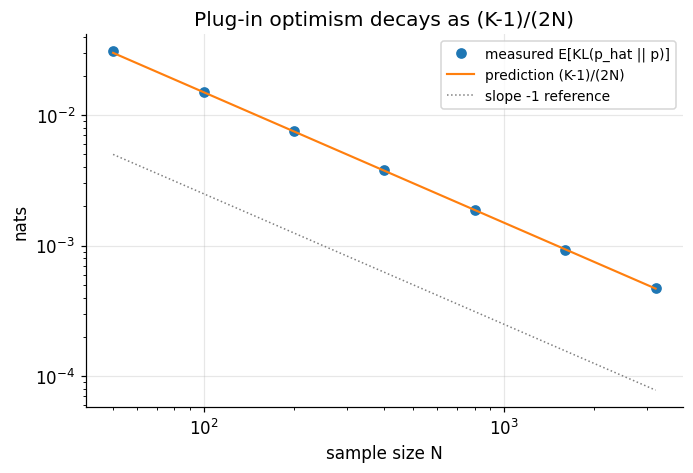

largest relative deviation from the prediction: 0.0265


In [7]:
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.loglog(Ns, means, "o", ms=6, label="measured E[KL(p_hat || p)]")
ax.loglog(Ns, pred, lw=1.4, label="prediction (K-1)/(2N)")
ax.loglog(Ns, 0.25 / Ns, lw=1.0, ls=":", color="0.5", label="slope -1 reference")
ax.set_xlabel("sample size N")
ax.set_ylabel("nats")
ax.set_title("Plug-in optimism decays as (K-1)/(2N)")
ax.legend(fontsize=9)
plt.show()

print(f"largest relative deviation from the prediction: {np.abs(means / pred - 1).max():.4f}")

The measured points sit on the predicted line over six doublings of $N$ and nearly two orders of
magnitude of optimism, with a largest relative deviation of $2.7$ percent.

That agreement is the practical content of Proposition 4.10: a training cross-entropy is biased
low by half a nat per free parameter per sample, and the bias is predictable rather than
mysterious.

### 7.3 Three hypotheses, dropped

This cell removes one hypothesis at a time and shows what breaks.

- **Absolute continuity in Theorem 4.1.** Setting $q(x) = 0$ where $p(x) \gt 0$ makes
  $H_{\times}$ infinite; a sequence $q_\delta$ with $\delta \to 0$ shows the divergence is
  logarithmic, not a numerical artefact.
- **$K \ge 3$ in Theorem 4.7.** The binary Brier score $s(t) = 2(1-t)^2$ is local and strictly
  proper, and $t\,s'(t)$ is not constant — so it is not an affine transform of the log score.
- **$\sum_k y_k = 1$ in Theorem 4.5.** With targets summing to $1.5$, the true gradient is
  $\left(\sum_k y_k\right) q - y$ and the formula $q - y$ is simply wrong.
- **The prefix property in Theorem 4.2(a).** The code $\{0, 01, 1\}$ has Kraft sum $\tfrac54$ and
  parses the string $01$ two different ways.
- **$\epsilon \gt 0$ in Theorem 4.8.** The optimal logit gap diverges logarithmically as the
  smoothing level goes to zero.

In [8]:
print("(i) absolute continuity")
p73 = np.array([0.5, 0.3, 0.2])
print(f"  H_x with q = (0.5, 0.5, 0.0): {cross_entropy(p73, np.array([0.5, 0.5, 0.0])):.6f} bits")
for delta in [1e-3, 1e-6, 1e-9, 1e-12]:
    q_d = np.array([0.5, 0.5 - delta, delta])
    print(f"    delta = {delta:.0e}   H_x = {cross_entropy(p73, q_d):8.4f} bits"
          f"   KL = {kl(p73, q_d):8.4f} bits")
assert np.isinf(cross_entropy(p73, np.array([0.5, 0.5, 0.0])))

print("\n(ii) K = 2 defeats the locality theorem")
grid73 = np.linspace(0.05, 0.95, 7)
s_brier_deriv = -4.0 * (1.0 - grid73)
print("  t            :", np.round(grid73, 3))
print("  t s'(t), Brier:", np.round(grid73 * s_brier_deriv, 4), " <- not constant")
print("  t s'(t), log  :", np.round(grid73 * (-1.0 / grid73), 4), " <- constant")
fine = np.linspace(0.001, 0.999, 999)
for c in [0.2, 0.5, 0.8]:
    exp_brier = c * 2 * (1 - fine) ** 2 + (1 - c) * 2 * fine ** 2
    print(f"  truth c = {c}: argmin of expected binary Brier = {fine[exp_brier.argmin()]:.3f}"
          f"  (strictly proper)")
    assert abs(fine[exp_brier.argmin()] - c) < 2e-3
assert np.ptp(grid73 * s_brier_deriv) > 0.5

print("\n(iii) targets that do not sum to one")
z73 = np.array([2.0, 0.0, -1.0])
q73 = np.exp(z73) / np.exp(z73).sum()
y73 = np.array([1.0, 0.0, 0.5])


def loss73(z, y):
    return float(-(y * (z - np.log(np.exp(z).sum()))).sum())


h, g_num = 1e-6, np.zeros(3)
for i in range(3):
    step = np.zeros(3)
    step[i] = h
    g_num[i] = (loss73(z73 + step, y73) - loss73(z73 - step, y73)) / (2 * h)
print("  sum of targets        :", y73.sum())
print("  numerical gradient    :", np.round(g_num, 6))
print("  formula q - y         :", np.round(q73 - y73, 6), " <- wrong")
print("  correct (sum y) q - y :", np.round(y73.sum() * q73 - y73, 6))
assert np.abs(g_num - (q73 - y73)).max() > 0.1
assert np.abs(g_num - (y73.sum() * q73 - y73)).max() < 1e-6

print("\n(iv) a code without the prefix property")
code = {"a": "0", "b": "01", "c": "1"}
kraft = sum(2.0 ** -len(w) for w in code.values())
print("  code           :", code)
print(f"  Kraft sum      : {kraft:.4f}   (Theorem 4.2(a) would force <= 1)")
print("  the string '01' parses as", [k for k, w in code.items() if w == "01"],
      "or as", [k for k, w in code.items() if w == "0"], "+", [k for k, w in code.items() if w == "1"])
assert kraft > 1.0

print("\n(v) label smoothing as epsilon goes to zero")
K73 = 10
for e in [0.2, 0.1, 0.01, 1e-4, 1e-8]:
    gap = np.log(((1 - e) * K73 + e) / e)
    print(f"  epsilon = {e:.0e}   optimal confidence = {1 - e + e / K73:.8f}"
          f"   optimal logit gap = {gap:8.4f}")
assert np.log(((1 - 1e-8) * K73 + 1e-8) / 1e-8) > np.log(((1 - 0.2) * K73 + 0.2) / 0.2)

(i) absolute continuity
  H_x with q = (0.5, 0.5, 0.0): inf bits
    delta = 1e-03   H_x =   2.7940 bits   KL =   1.3085 bits
    delta = 1e-06   H_x =   4.7863 bits   KL =   3.3008 bits
    delta = 1e-09   H_x =   6.7795 bits   KL =   5.2940 bits
    delta = 1e-12   H_x =   8.7726 bits   KL =   7.2872 bits

(ii) K = 2 defeats the locality theorem
  t            : [0.05 0.2  0.35 0.5  0.65 0.8  0.95]
  t s'(t), Brier: [-0.19 -0.64 -0.91 -1.   -0.91 -0.64 -0.19]  <- not constant
  t s'(t), log  : [-1. -1. -1. -1. -1. -1. -1.]  <- constant
  truth c = 0.2: argmin of expected binary Brier = 0.200  (strictly proper)
  truth c = 0.5: argmin of expected binary Brier = 0.500  (strictly proper)
  truth c = 0.8: argmin of expected binary Brier = 0.800  (strictly proper)

(iii) targets that do not sum to one
  sum of targets        : 1.5
  numerical gradient    : [ 0.2657  0.1713 -0.437 ]
  formula q - y         : [-0.1562  0.1142 -0.458 ]  <- wrong
  correct (sum y) q - y : [ 0.2657  0.1713 -0.

The first block prints an infinite cross-entropy, then shows the finite approximations growing
like $-p(x)\log_2 \delta$: at $\delta = 10^{-12}$ the bill is $8.77$ bits for a source whose
entropy is $1.49$ bits. A single declared-impossible event that then occurs dominates any amount
of good prediction elsewhere.

The second block confirms that the binary Brier score is strictly proper — its expected score is
minimized at the true $c$ for every $c$ tested — while $t\,s'(t)$ ranges over $[-1, -0.19]$
instead of being constant. Theorem 4.7 is therefore genuinely false at $K = 2$, which is why the
hypothesis is stated.

The third block shows the formula $q - y$ failing by $0.42$ in the first coordinate when the
targets sum to $1.5$ — it even gets the sign wrong — while the corrected
$\left(\sum_k y_k\right) q - y$ matches central differences to six decimals.

The fourth block prints a Kraft sum of $1.25$ for a code that is not prefix-free, so
Theorem 4.2(a) genuinely needs its hypothesis; the same code parses $01$ both as one symbol and
as two, which is why the prefix property is the right condition to impose.

The fifth block watches the optimal logit gap of Theorem 4.8 grow like $\log(1/\epsilon)$: it is
$3.71$ at $\epsilon = 0.2$ and $20.72$ at $\epsilon = 10^{-8}$, diverging as the smoothing is
removed. That divergence is the vertex optimum that hard targets ask the optimizer to reach.

### 7.4 Hand-rolled against SciPy

This cell checks three implementations against the library:

- a max-shifted `log_softmax` against `scipy.special.log_softmax`, including the overflow case
  $z = (800, 0, -800)$ where the naive formula returns `nan`;
- the stable BCE-with-logits form $\max(z,0) - zy + \log(1 + e^{-\lvert z \rvert})$ against the
  naive $-y\log \sigma(z) - (1-y)\log(1 - \sigma(z))$;
- the analytic gradient $q - y$ of Theorem 4.5 against central differences.

In [9]:
from scipy.special import log_softmax as sp_log_softmax


def my_log_softmax(z):
    m = z.max(axis=-1, keepdims=True)
    return z - m - np.log(np.exp(z - m).sum(axis=-1, keepdims=True))


Zrand = rng.normal(0.0, 5.0, size=(6, 5))
gap = np.abs(my_log_softmax(Zrand) - sp_log_softmax(Zrand, axis=-1)).max()
print(f"max |mine - scipy.special.log_softmax| = {gap:.3e}   ({gap / EPS:.1f} * eps)")

z_big = np.array([800.0, 0.0, -800.0])
with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
    naive = np.log(np.exp(z_big) / np.exp(z_big).sum())
print("naive  log softmax at z = (800, 0, -800):", naive)
print("stable log softmax at z = (800, 0, -800):", my_log_softmax(z_big))
print("scipy                                   :", sp_log_softmax(z_big))


def bce_with_logits(z, y):
    return np.maximum(z, 0.0) - z * y + np.log1p(np.exp(-np.abs(z)))


z_bce = np.array([-800.0, -30.0, 0.0, 30.0, 800.0])
y_bce = np.ones_like(z_bce)
with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
    sig = 1.0 / (1.0 + np.exp(-z_bce))
    naive_bce = -y_bce * np.log(sig) - (1 - y_bce) * np.log(1 - sig)
print("\nz      :", z_bce)
print("naive  :", naive_bce)
print("stable :", bce_with_logits(z_bce, y_bce))

y_soft = np.array([0.7, 0.2, 0.1])
z_g = np.array([0.4, -1.2, 0.9])
q_g = np.exp(z_g) / np.exp(z_g).sum()
g_fd = np.zeros(3)
for i in range(3):
    step = np.zeros(3)
    step[i] = 1e-6
    g_fd[i] = (-(y_soft * sp_log_softmax(z_g + step)).sum()
               + (y_soft * sp_log_softmax(z_g - step)).sum()) / 2e-6
print("\nanalytic gradient q - y :", np.round(q_g - y_soft, 8))
print("central differences     :", np.round(g_fd, 8))
print(f"max difference          : {np.abs(g_fd - (q_g - y_soft)).max():.3e}")
assert gap < 8 * EPS
assert np.isfinite(bce_with_logits(z_bce, y_bce)).all()
assert not np.isfinite(naive_bce).all()
assert np.abs(g_fd - (q_g - y_soft)).max() < 1e-8

max |mine - scipy.special.log_softmax| = 0.000e+00   (0.0 * eps)
naive  log softmax at z = (800, 0, -800): [ nan -inf -inf]
stable log softmax at z = (800, 0, -800): [    0.  -800. -1600.]
scipy                                   : [    0.  -800. -1600.]

z      : [-800.  -30.    0.   30.  800.]
naive  : [    inf 30.      0.6931  0.         nan]
stable : [800.      30.       0.6931   0.       0.    ]

analytic gradient q - y : [-0.3492 -0.1292  0.4784]
central differences     : [-0.3492 -0.1292  0.4784]
max difference          : 7.640e-11


The hand-written `log_softmax` agrees with SciPy to zero difference on well-scaled inputs, and
both survive $z = 800$ where the textbook formula returns `nan` and $-\infty$.

The naive BCE returns `inf` at $z = -800$ and `nan` at $z = +800$; the stable form returns the
mathematically correct $800$ and $0$. This is exactly why `BCEWithLogitsLoss` exists and why
passing already-normalized probabilities into a logits loss is a silent bug.

The analytic gradient matches central differences to $8 \times 10^{-11}$, confirming Theorem 4.5
on a soft target rather than a one-hot one.

### 7.5 The vanishing-gradient plateau

The last figure plots the two loss curves of Theorem 4.9 and the magnitude of their logit
gradients for a positive label $y = 1$, over $z \in [-8, 8]$.

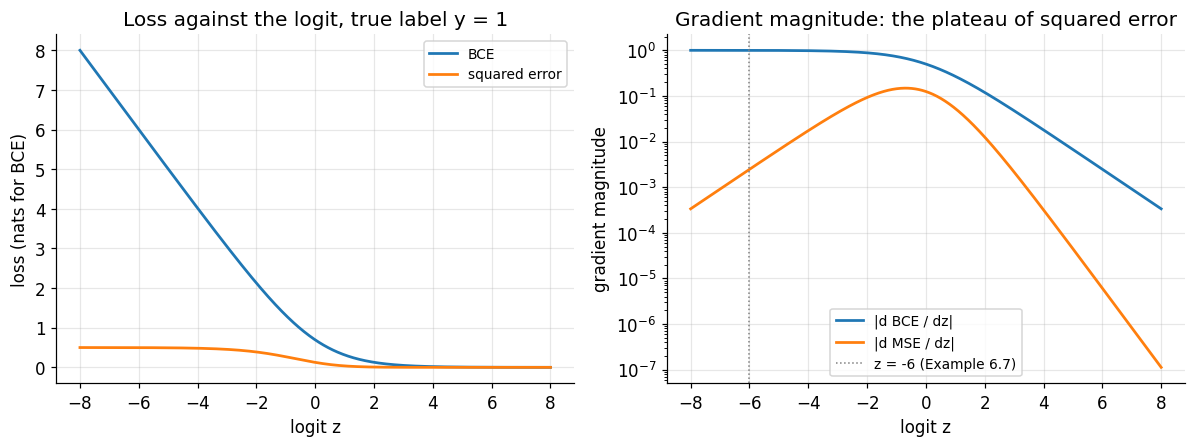

z =  -2.0   |d BCE/dz| = 0.880797   |d MSE/dz| = 9.248e-02   ratio =       9.5
z =  -4.0   |d BCE/dz| = 0.982014   |d MSE/dz| = 1.735e-02   ratio =      56.6
z =  -6.0   |d BCE/dz| = 0.997527   |d MSE/dz| = 2.460e-03   ratio =     405.4
z =  -8.0   |d BCE/dz| = 0.999665   |d MSE/dz| = 3.351e-04   ratio =    2983.0


In [10]:
z_axis = np.linspace(-8.0, 8.0, 801)
sig_axis = 1.0 / (1.0 + np.exp(-z_axis))
bce_curve = np.log1p(np.exp(-z_axis))
mse_curve = 0.5 * (sig_axis - 1.0) ** 2
g_bce = np.abs(sig_axis - 1.0)
g_mse = np.abs((sig_axis - 1.0) * sig_axis * (1 - sig_axis))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.2))

ax1.plot(z_axis, bce_curve, lw=1.8, label="BCE")
ax1.plot(z_axis, mse_curve, lw=1.8, label="squared error")
ax1.set_xlabel("logit z")
ax1.set_ylabel("loss (nats for BCE)")
ax1.set_title("Loss against the logit, true label y = 1")
ax1.legend(fontsize=9)

ax2.semilogy(z_axis, g_bce, lw=1.8, label="|d BCE / dz|")
ax2.semilogy(z_axis, g_mse, lw=1.8, label="|d MSE / dz|")
ax2.axvline(-6.0, lw=1.0, ls=":", color="0.5", label="z = -6 (Example 6.7)")
ax2.set_xlabel("logit z")
ax2.set_ylabel("gradient magnitude")
ax2.set_title("Gradient magnitude: the plateau of squared error")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

for z0 in [-2.0, -4.0, -6.0, -8.0]:
    s0 = 1.0 / (1.0 + np.exp(-z0))
    print(f"z = {z0:5.1f}   |d BCE/dz| = {abs(s0 - 1):.6f}"
          f"   |d MSE/dz| = {abs((s0 - 1) * s0 * (1 - s0)):.3e}"
          f"   ratio = {1 / (s0 * (1 - s0)):9.1f}")

The BCE curve grows linearly in $-z$ and its gradient saturates at $1$; the squared-error curve
flattens to a plateau of height $\tfrac12$ and its gradient collapses.

The printed ratios grow from $9.5$ at $z = -2$ to $2983$ at $z = -8$, and they equal
$1/\left(\sigma(z)(1-\sigma(z))\right)$ exactly. A network trained with squared error on sigmoid
outputs therefore learns most slowly precisely where it is most wrong, which is the practical
content of Theorem 4.9.

## 8. Applications

Four settings use Theorem 4.1 as their engine. In each the object being minimized is a
cross-entropy for a structural reason, not by analogy.

### 8.1 Language models: loss, perplexity, and compression

A language model reports a distribution over the next token, and its training objective is the
empirical cross-entropy of the data against that distribution, which by Theorem 4.4 is the
negative log-likelihood per token.

Two conventional rescalings are used:

$$
\mathrm{PPL} = e^{\mathrm{CE}}, \qquad \text{bits per token} = \frac{\mathrm{CE}}{\ln 2} .
$$

By Theorem 4.3 the bits-per-token figure is, to within one bit, the size of the file an
arithmetic coder driven by the model would produce. Cross-entropy progress is compression
progress, in the literal sense that both numbers are the same number.

The floor is $H(Y \mid X)$, the conditional entropy of the next token given the context, which
is developed in [Module 02](../02_joint_and_conditional_entropy/first_principles.ipynb). A
reported test loss below that floor is a bug or a leak, never an achievement.

### 8.2 Calibration and temperature scaling

Theorem 4.6 says a fully minimized cross-entropy produces honest probabilities. Networks
trained to near-zero training loss overshoot: they are minimized against the *training*
empirical distribution and end up overconfident on new data.

Temperature scaling repairs this with a single scalar $T$ fitted on held-out data by minimizing
the same loss:

$$
q_T = \operatorname{softmax}(z / T) .
$$

Because the log score is strictly proper, the fitted $T$ recovers the transformation that makes
the reported probabilities match the conditional frequencies — no other criterion is needed.
The experiment below constructs logits that are overconfident by a known factor and checks that
the fitted temperature recovers it.

### 8.3 Gambling: the doubling rate

A gambler places fractions $b_x$ of wealth on the outcomes of a race with true probabilities $p$
and payoff odds $o_x$ (a winning bet on $x$ returns $o_x$ times the stake). Wealth multiplies by
$o_x b_x$ when $x$ occurs, so after $n$ independent races the law of large numbers gives the
asymptotic growth rate

$$
W(b) = \sum_x p(x) \log \left(o_x b_x\right) \ \text{bits per race} .
$$

For **fair odds** $o_x = K$ this specializes to

$$
W(b) = \log K - H_{\times}(p, b),
$$

so maximizing growth is minimizing cross-entropy and the optimum is $b^{\star} = p$ by
Theorem 4.1, with $W^{\star} = \log K - H(p)$.

The $\log K$ term is not a detail: it is what makes $W^{\star}$ positive for a good bettor.
Betting beliefs $q$ instead of $p$ costs exactly $D_{\mathrm{KL}}(p \parallel q)$ bits of growth
per race. Problem L3.3 of the exercises derives this, and a track take that reduces $o_x$ below
$K$ subtracts a constant from $W$ that can make even a perfect bettor lose.

### 8.4 Statistical mechanics: free energy is a cross-entropy

For a system with energy levels $E_x$ at temperature $T$, the Gibbs variational principle
minimizes the free energy

$$
F(q) = \mathbb{E}_q[E] - k_B T \, H(q) \quad \text{(entropy in nats)}
$$

over distributions $q$. Writing the Boltzmann distribution as
$p^{\star}(x) = e^{-E_x / k_B T} / Z$ gives $E_x = -k_B T \log\left(Z\, p^{\star}(x)\right)$, so

$$
\mathbb{E}_q[E] = k_B T \, H_{\times}(q, p^{\star}) - k_B T \log Z,
$$

and therefore

$$
F(q) = -k_B T \log Z + k_B T \, D_{\mathrm{KL}}(q \parallel p^{\star}) .
$$

Mean energy *is* a cross-entropy, up to $k_B T$ and an additive constant, and the free energy
excess of any trial distribution over equilibrium is $k_B T$ times a KL divergence — which is
non-negative by Theorem 4.1. That is the second law in the form used by variational inference,
where the same algebra names $-F$ the ELBO. Problem L2.8 of the exercises puts numbers on a
two-level system.

The cell below runs the three computational applications: the perplexity arithmetic of 8.1,
temperature scaling on synthetic overconfident logits for 8.2, and a simulated betting sequence
for 8.3.

In [11]:
from scipy.optimize import minimize_scalar

# --- 8.1 perplexity and compression -------------------------------------
ce_a, ce_b = 3.466, 3.120
bits_a, bits_b = ce_a / np.log(2), ce_b / np.log(2)
print("8.1 language models")
print(f"  model A: CE = {ce_a} nats -> PPL {np.exp(ce_a):.2f}, {bits_a:.4f} bits/token")
print(f"  model B: CE = {ce_b} nats -> PPL {np.exp(ce_b):.2f}, {bits_b:.4f} bits/token")
print(f"  saving  : {bits_a - bits_b:.4f} bits/token"
      f"  ->  {(bits_a - bits_b) * 1e9 / 8 / 1e6:.1f} MB per 10^9 tokens")

# --- 8.2 temperature scaling --------------------------------------------
N82, K82, sharpen = 4000, 5, 1.8
Ptrue = rng.dirichlet(np.ones(K82), size=N82)
labels = (Ptrue.cumsum(axis=1) < rng.random((N82, 1))).sum(axis=1)
logits82 = sharpen * np.log(Ptrue)


def nll_at(T):
    return float(-np.mean(sp_log_softmax(logits82 / T, axis=1)[np.arange(N82), labels]))


opt = minimize_scalar(nll_at, bounds=(0.2, 6.0), method="bounded")
floor82 = float(np.mean([entropy(Ptrue[i], np.e) for i in range(N82)]))
print("\n8.2 temperature scaling")
print(f"  overconfidence factor built in : {sharpen}")
print(f"  NLL at T = 1                   : {nll_at(1.0):.5f} nats")
print(f"  fitted temperature             : {opt.x:.4f}")
print(f"  NLL at the fitted T            : {opt.fun:.5f} nats")
print(f"  mean entropy of the true probs : {floor82:.5f} nats  (the floor)")
assert abs(opt.x - sharpen) < 0.05
assert opt.fun < nll_at(1.0)

# --- 8.3 doubling rate ---------------------------------------------------
p83 = np.array([0.5, 0.25, 0.125, 0.125])
K83 = p83.size
u83 = np.full(K83, 1.0 / K83)
races = 4000
draws = rng.choice(K83, size=races, p=p83)
print("\n8.3 Kelly betting at fair odds o = K = 4")
for name, b in [("b = p (Kelly)", p83), ("b = uniform", u83)]:
    predicted = np.log2(K83) - cross_entropy(p83, b)
    measured = float(np.log2(K83 * b[draws]).mean())
    print(f"  {name:14s} predicted W = {predicted:+.5f} bits/race,"
          f" measured {measured:+.5f}")
print(f"  loss from betting uniform      : {kl(p83, u83):.5f} bits/race = D_KL(p || u)")
print(f"  with a 20 percent track take, o = 3.2: W(p) = {np.log2(3.2) - entropy(p83):+.5f} bits/race")
assert abs((np.log2(K83) - cross_entropy(p83, p83)) - kl(p83, u83)) < 8 * EPS

8.1 language models
  model A: CE = 3.466 nats -> PPL 32.01, 5.0004 bits/token
  model B: CE = 3.12 nats -> PPL 22.65, 4.5012 bits/token
  saving  : 0.4992 bits/token  ->  62.4 MB per 10^9 tokens

8.2 temperature scaling
  overconfidence factor built in : 1.8
  NLL at T = 1                   : 1.38534 nats
  fitted temperature             : 1.7856
  NLL at the fitted T            : 1.28445 nats
  mean entropy of the true probs : 1.28787 nats  (the floor)

8.3 Kelly betting at fair odds o = K = 4
  b = p (Kelly)  predicted W = +0.25000 bits/race, measured +0.25825
  b = uniform    predicted W = +0.00000 bits/race, measured +0.00000
  loss from betting uniform      : 0.25000 bits/race = D_KL(p || u)
  with a 20 percent track take, o = 3.2: W(p) = -0.07193 bits/race


The perplexity arithmetic shows what a $0.35$-nat improvement means operationally: perplexity
falls from $32.01$ to $22.65$ and the same corpus compresses $62$ MB smaller per billion tokens.

Temperature scaling recovers a fitted $T = 1.7856$ against a built-in overconfidence of $1.8$,
and the loss falls from $1.38534$ to $1.28445$ nats.

The population floor — the mean entropy of the true conditional distributions — is $1.28787$
nats, and the fitted loss sits $0.003$ nats below it, which is ordinary finite-sample
fluctuation on $4000$ examples. Strict propriety is doing the work: nothing in the fit knows the
true probabilities, only the labels.

Over $4000$ simulated races the Kelly bettor grows at $0.2583$ bits per race against a predicted
$0.2500$, the difference being sampling fluctuation; uniform betting at fair odds grows at
exactly zero rate, because $\log_2 K - H_{\times}(p, u) = 0$ identically.

The gap between the two is $0.25$ bits per race — the same KL divergence that Example 6.2 charged
as extra code length. With a $20$ percent track take even the Kelly bettor loses $0.072$ bits per
race.

## 9. Key Takeaways

- **The decomposition is the module.** $H_{\times}(p, q) = H(p) + D_{\mathrm{KL}}(p \parallel q)$
  with $D_{\mathrm{KL}} \ge 0$ and equality only at $q = p$ (Theorem 4.1). The floor $H(p)$ is
  untouchable; everything a model can improve is the second term.

- **Cross-entropy is a code length to within one bit.** The Shannon code for $q$ satisfies
  $H(p) + D_{\mathrm{KL}} \le \mathbb{E}_p[\ell_q] \lt H(p) + D_{\mathrm{KL}} + 1$
  (Theorem 4.3), and the code exists because of Kraft (Theorem 4.2). The coding story is a
  theorem, not a metaphor.

- **Maximum likelihood is cross-entropy minimization** against the empirical distribution, and
  equivalently a forward-KL projection (Theorem 4.4). The data always occupies the first
  argument.

- **The softmax gradient is $q - y$** and the Hessian is $\operatorname{diag}(q) - qq^{\top}$,
  a covariance matrix, so the per-example loss is convex in the logits with one flat direction
  (Theorem 4.5).

- **Log loss cannot be gamed, and locality forces it.** Honest reporting is uniquely optimal
  (Theorem 4.6), and among rules that see only the probability assigned to what happened, the
  logarithm is the only proper one once $K \ge 3$ (Theorem 4.7). At $K = 2$ the binary Brier
  score is a genuine counterexample, run in Section 7.3.

- **Label smoothing moves the optimum inside the simplex**: optimal confidence
  $1 - \epsilon + \epsilon/K$ and a finite optimal logit gap (Theorem 4.8), instead of a vertex
  reachable only at infinite logits.

- **Sigmoid pairs with cross-entropy, not with squared error.** The BCE gradient is
  $\sigma(z) - y$ and the loss is convex in $z$; squared error keeps a factor
  $\sigma(z)(1-\sigma(z))$ that is $405$ times smaller at $z = -6$ and vanishes as the model
  gets more confidently wrong (Theorem 4.9, Example 6.7).

- **Training loss is optimistic by $(K-1)/(2N)$ nats** (Proposition 4.10). Section 7.2 measures
  the exponent of $N$ as $-1.0046$ against the predicted $-1$.

## 10. References

**Textbooks.**

- Cover, T. M. and Thomas, J. A. *Elements of Information Theory*, 2nd ed. — Kraft's inequality
  and its converse (Theorem 5.2.1), optimal code lengths (section 5.3), the wrong-code theorem
  (Theorem 5.4.3), Shannon codes and competitive optimality (section 5.11), the doubling rate
  and Kelly gambling (Chapter 6, Theorem 6.1.2).
- MacKay, D. J. C. *Information Theory, Inference, and Learning Algorithms* — Chapter 4 (the
  source coding theorem), Chapter 5 (symbol codes and the $H \le \mathbb{E}[\ell] \lt H+1$
  bound), Chapter 6 (arithmetic coding as the practical realization).
- Goodfellow, I., Bengio, Y. and Courville, A. *Deep Learning* — section 5.5 (maximum
  likelihood as KL minimization), section 6.2.2 (softmax units and the log-likelihood loss),
  section 6.2.2.2 for the saturation argument reproved here as Theorem 4.9.
- Bishop, C. M. *Pattern Recognition and Machine Learning* — section 4.3.2 (logistic regression
  and the $\hat{p} - y$ gradient), section 4.3.4 (the multiclass case).
- Boyd, S. and Vandenberghe, L. *Convex Optimization*, section 3.5 — the log-sum-exp function,
  its convexity and its conjugate, which is the Hessian statement of Theorem 4.5.

**Papers.**

- Bernardo, J. M. "Expected information as expected utility", *Annals of Statistics* **7**(3)
  (1979), 686-690 — Theorem 1 is the locality characterization proved here, in its smooth form,
  as Theorem 4.7.
- Gneiting, T. and Raftery, A. E. "Strictly proper scoring rules, prediction, and estimation",
  *Journal of the American Statistical Association* **102**(477) (2007), 359-378 — sections 2
  and 3 for the Savage representation used in Problem L3.5.
- Good, I. J. "Rational decisions", *Journal of the Royal Statistical Society B* **14**(1)
  (1952), 107-114 — the logarithmic score.
- Szegedy, C., Vanhoucke, V., Ioffe, S., Shlens, J. and Wojna, Z. "Rethinking the Inception
  architecture for computer vision", CVPR (2016), section 7 — label smoothing.
- Müller, R., Kornblith, S. and Hinton, G. "When does label smoothing help?", NeurIPS (2019) —
  the calibration effect of Theorem 4.8.
- Lin, T.-Y., Goyal, P., Girshick, R., He, K. and Dollár, P. "Focal loss for dense object
  detection", ICCV (2017), section 3 — the $(1-q_t)^{\gamma}$ modulation of Problem L2.3.
- Hinton, G., Vinyals, O. and Dean, J. "Distilling the knowledge in a neural network",
  arXiv:1503.02531 (2015), section 2 — the temperature and the $T^2$ rescaling of Problem L2.4.
- Guo, C., Pleiss, G., Sun, Y. and Weinberger, K. Q. "On calibration of modern neural networks",
  ICML (2017), section 4.2 — temperature scaling as used in Section 8.2.
- Kelly, J. L. "A new interpretation of information rate", *Bell System Technical Journal*
  **35**(4) (1956), 917-926 — the doubling rate of Section 8.3.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions, including the $H(X,Y)$ against $H_{\times}(p,q)$ ruling:
  [the notation register](../../docs/notation.md).
- Entropy, the tangent-line bound and differential entropy:
  [Module 01](../01_self_information_and_entropy/).
- Conditional entropy, the chain rule and the loss floor $H(Y \mid X)$:
  [Module 02](../02_joint_and_conditional_entropy/).
- The generalization of Definition 3.2 to $f$-divergences, and forward against reverse KL:
  [Module 04](../04_kl_divergence_and_f_divergences/).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).